# WBS Coding School — Student Review Sentiment Analysis

This notebook performs a full sentiment and topic analysis on cleaned WBS Coding School
student reviews. It is designed to answer three core business questions:

    1. Product Evaluation:   Which aspects of the course receive the most feedback?
                             What motivates positive reviews?

    2. Product Improvement:  Are there recurring pain points or recommendations
                             we should be addressing?

    3. Marketing:            Which reviews contain quotes or testimonials strong
                             enough to use on the website or in marketing materials?

The notebook loads data directly from the cleaning pipeline so it always reflects
the most current version of the dataset. All charts are saved automatically to
the shared drive for use in presentations and reports.

In [1]:
!pip install vaderSentiment -q
!pip install lingua-language-detector deep-translator -q
!pip install wordcloud scikit-learn -q
!pip install thefuzz python-Levenshtein -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 973.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.8 MB/s eta 0:00:00


#Imports

In [2]:
# Environment Setup

from google.colab import drive
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from itertools import combinations
from collections import Counter
from importlib import reload

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define paths
BASE_DIR   = '/content/drive/Shareddrives/essentis_intern_drive'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
SRC_DIR    = os.path.join(DATA_DIR, 'src_reviews_cleaning')
CHARTS_DIR = os.path.join(BASE_DIR, 'charts', 'sentiment')
EXPORT_DIR = os.path.join(BASE_DIR, 'charts', 'sentiment', 'exports')

# Add src package to Python path
if DATA_DIR not in sys.path:
    sys.path.insert(0, DATA_DIR)

# Create output directories
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)

# Apply seaborn theme
sns.set_theme()

print("Setup complete.")
print("SRC_DIR exists:  ", os.path.exists(SRC_DIR))
print("CHARTS_DIR:      ", CHARTS_DIR)
print("EXPORT_DIR:      ", EXPORT_DIR)

Mounted at /content/drive
Setup complete.
SRC_DIR exists:   True
CHARTS_DIR:       /content/drive/Shareddrives/essentis_intern_drive/charts/sentiment
EXPORT_DIR:       /content/drive/Shareddrives/essentis_intern_drive/charts/sentiment/exports


#Load Data

Data is loaded directly from the cleaning pipeline rather than from a saved CSV file.
This means the sentiment analysis always runs on the most up to date version of the
cleaned dataset without any manual file management.

The pipeline returns 843 reviews from three original sources: Google Maps (256),
a previously cleaned CSV (541), and the most recent batch (49). Three duplicate
reviews were removed during cleaning, leaving 843 unique entries.

A new column called text_for_analysis is created here. For the 40 non-English reviews
(mostly German, one French), this column contains the English translation produced
by the cleaning pipeline. For all other reviews it contains the original review text.
This ensures all downstream sentiment scoring is performed on English text.

In [3]:
# Loads the cleaned reviews DataFrame directly from the pipeline.
# This ensures the sentiment analysis always uses the most up to date data.
# review_text_translated is used for sentiment scoring where available
# so that non-English reviews (German, French) are scored correctly.
# A new column text_for_analysis is created as the single text column
# used by all downstream cells.

import src_reviews_cleaning.pipeline as P
reload(P)

df = P.run(save_csv=False)

# Use translated text for non-English reviews, original for English
df['text_for_analysis'] = df['review_text_translated'].where(
    df['review_text_translated'].notna(), df['review_text']
)

# Drop rows with no usable text
df = df.dropna(subset=['text_for_analysis']).reset_index(drop=True)

print("Shape:", df.shape)
print("Using translated text for:", df['review_text_translated'].notna().sum(), "reviews")
print("Using original text for:",   df['review_text_translated'].isna().sum(),  "reviews")
print("\nSample text_for_analysis:")
print(df['text_for_analysis'].iloc[0][:150])

Step 1/4: Loading raw data...
  google: 256 rows
  clean: 541 rows
  new: 49 rows
Step 2/4: Normalizing columns...


/content/drive/Shareddrives/essentis_intern_drive/data/src_reviews_cleaning/normalizers.py:297: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(normalized, ignore_index=True)


  Combined shape: (846, 17)
Step 3/4: Cleaning data (includes language detection + translation)...
  [17/846] Translated from FRENCH: Très bonne école de formation. Les cours sont bien...
  [206/846] Translated from GERMAN: Der KI Kompaktkurs bei WBS Coding School bietet ei...
  [207/846] Translated from GERMAN: Abhängig vom eigenen Skillset und der jeweiligen G...
  [208/846] Translated from GERMAN: Der AI Compact-Kurs war ausgezeichnet. Er hat mir ...
  [209/846] Translated from GERMAN: Von Mai bis Juli 2025 habe ich an der WBS eine Wei...
  [210/846] Translated from GERMAN: Das Bootcamp "AI for Business" war für mich ein ec...
  [211/846] Translated from GERMAN: Ich habe den Data Science-Kurs abgeschlossen und e...
  [212/846] Translated from GERMAN: Anfangs war ich unsicher, ob mein Vorwissen für da...
  [213/846] Translated from GERMAN: Ich bin mit wenig Programmier-Erfahrung ins Data S...
  [214/846] Translated from GERMAN: Ich habe in den letzten 8 Wochen am KI-Kurs der WB...
  

# VADER sentiment scoring

# What is VADER?

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment
analysis tool specifically designed for short, informal text like social media posts,
product reviews, and online comments. Unlike machine learning models, VADER does not
need to be trained — it uses a hand-crafted dictionary of words and rules that have
been validated by human raters.


---


## How does VADER work?

VADER works by looking up each word in a review against its sentiment dictionary.
Every word in the dictionary has been assigned a valence score — a number representing
how positive or negative that word is. For example:

    "excellent"  →  +3.0   (strongly positive)
    "bad"        →  -2.0   (moderately negative)
    "okay"       →  +0.9   (mildly positive)

VADER then applies a set of grammatical rules to adjust these scores based on context:

    Capitalization:  "EXCELLENT" scores higher than "excellent"
    Intensifiers:    "very good" scores higher than "good"
    Negation:        "not good" flips the polarity of "good"
    Punctuation:     "great!!!" scores higher than "great"
    Contrast:        "good but disappointing" is weighted towards the negative


---


## What scores does VADER produce?

VADER produces four scores for each piece of text:

    pos:      Proportion of the text that is positive (0 to 1)
    neu:      Proportion of the text that is neutral (0 to 1)
    neg:      Proportion of the text that is negative (0 to 1)
    compound: An overall score normalized between -1 (most negative)
              and +1 (most positive)

The compound score is the most useful single measure and is used throughout
this notebook as the primary sentiment indicator.


---


## How are reviews labeled?

Based on standard VADER thresholds, reviews are labeled as:

    positive:  compound >= 0.05
    neutral:   compound between -0.05 and 0.05
    negative:  compound <= -0.05


---


## Limitations

VADER was designed for English text. Although non-English reviews have been
translated before scoring, machine translation introduces some inaccuracies
and translated text may not always preserve the original tone perfectly.
VADER also tends to score enthusiastic review-style language very positively,
which may result in a higher proportion of positive labels than a human reader
would assign. Results should be interpreted with this in mind.

NOTE: Language Detection + Translation (To Do)
Some reviews are written in German. VADER is English-only, which means
German reviews may be scored incorrectly. A future improvement would be
to detect the language of each review and translate non-English reviews
before running sentiment analysis. Consider using googletrans or the
Google Cloud Translation API for this.

In [4]:
# Cell 3: VADER Sentiment Scoring
# Scores each review using the VADER sentiment analyzer.
# VADER produces four scores per review:
#   pos:      proportion of text that is positive
#   neu:      proportion of text that is neutral
#   neg:      proportion of text that is negative
#   compound: overall score from -1 (most negative) to +1 (most positive)
#
# The compound score is used as the primary sentiment measure.
# Reviews are then labeled based on compound score thresholds:
#   positive: compound >= 0.05
#   neutral:  compound between -0.05 and 0.05
#   negative: compound <= -0.05
#
# text_for_analysis is used as input so non-English reviews are scored
# on their English translations rather than the original text.

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text: str) -> dict:
    """
    Calculate VADER sentiment scores for a single review text.

    Args:
        text (str): Review text to score.

    Returns:
        dict: Keys are pos, neu, neg, compound.
    """
    return analyzer.polarity_scores(str(text))

def get_sentiment_label(compound: float) -> str:
    """
    Convert a VADER compound score to a human readable sentiment label.

    Args:
        compound (float): VADER compound score between -1 and +1.

    Returns:
        str: "positive", "neutral", or "negative".
    """
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"

# Apply VADER to every review using text_for_analysis
scores = df['text_for_analysis'].apply(get_sentiment_scores)
df['sentiment_pos']      = scores.apply(lambda x: x['pos'])
df['sentiment_neu']      = scores.apply(lambda x: x['neu'])
df['sentiment_neg']      = scores.apply(lambda x: x['neg'])
df['sentiment_compound'] = scores.apply(lambda x: x['compound'])
df['sentiment_label']    = df['sentiment_compound'].apply(get_sentiment_label)

print("Sentiment scores calculated.")
print("\nSentiment label breakdown:")
print(df['sentiment_label'].value_counts())
print("\nCompound score summary:")
print(df['sentiment_compound'].describe().round(3))

Sentiment scores calculated.

Sentiment label breakdown:
sentiment_label
positive    791
negative     14
neutral      13
Name: count, dtype: int64

Compound score summary:
count    818.000
mean       0.862
std        0.268
min       -0.959
25%        0.875
50%        0.964
75%        0.989
max        1.000
Name: sentiment_compound, dtype: float64


# Sentiment Distribution

This section visualizes the overall sentiment breakdown across all 822 reviews
that contain usable text. The two charts show the count of positive, neutral,
and negative reviews and the full distribution of compound scores.

A healthy dataset of course reviews would be expected to skew positive since
students who complete a bootcamp and take the time to leave a review are
generally more satisfied than dissatisfied. A very high positive proportion
(above 90%) may also reflect VADER's tendency to score enthusiastic review
language as strongly positive even when reviews contain some criticism.

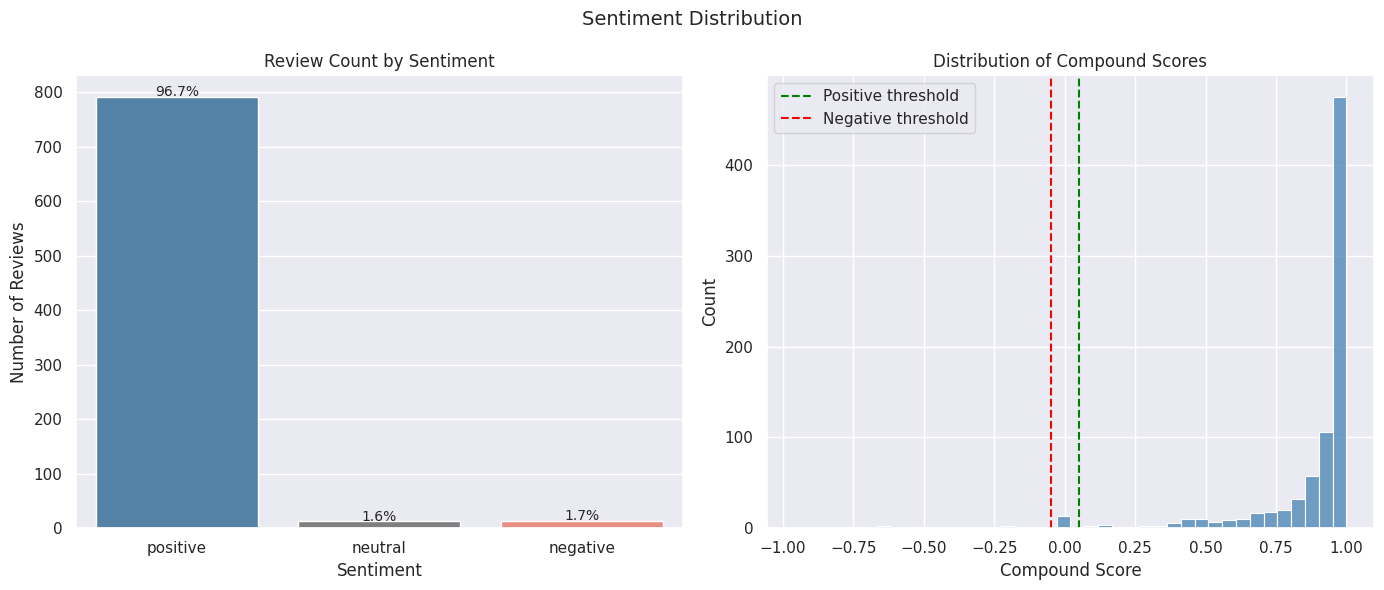

Saved: sentiment_distribution.png


In [5]:
# Sentiment Distribution Chart
# Visualizes the overall sentiment breakdown across all reviews.
# Chart 1: count of positive, neutral, and negative reviews with percentages
# Chart 2: histogram of compound scores with threshold lines

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Sentiment Distribution", fontsize=14)

palette     = {'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'}
label_order = ['positive', 'neutral', 'negative']
total       = len(df)

# Chart 1: count per sentiment label
label_counts = df['sentiment_label'].value_counts().reset_index()
label_counts.columns = ['sentiment', 'count']
sns.barplot(
    data=label_counts, x='sentiment', y='count',
    hue='sentiment', legend=False,
    order=label_order, palette=palette, ax=axes[0]
)
axes[0].set_title("Review Count by Sentiment")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Reviews")
for p in axes[0].patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    axes[0].annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                     ha='center', fontsize=10)

# Chart 2: distribution of compound scores
sns.histplot(data=df, x='sentiment_compound', bins=40, ax=axes[1], color='steelblue')
axes[1].axvline(0.05,  color='green', linestyle='--', label='Positive threshold')
axes[1].axvline(-0.05, color='red',   linestyle='--', label='Negative threshold')
axes[1].set_title("Distribution of Compound Scores")
axes[1].set_xlabel("Compound Score")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sentiment_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sentiment_distribution.png")

#Aspect Analysis — Keyword Matching

## What is aspect-based analysis?

Standard sentiment analysis tells us whether a review is positive or negative overall.
Aspect-based analysis goes deeper by identifying which specific topics are being
discussed and how people feel about each one.

### How does keyword matching work?

Each aspect (e.g. Teaching Quality, Career Support) is defined by a list of keywords.
A review is counted as mentioning an aspect if it contains at least one of that
aspect's keywords anywhere in the text. For example:

    Teaching Quality keywords: instructor, teacher, mentor, coaching, explain, taught, lecture
    A review containing "the instructors were fantastic" → counted for Teaching Quality

A single review can mention multiple aspects simultaneously. The results show both
how often each aspect is mentioned and what proportion of those mentions are positive,
neutral, or negative.

### Why keyword matching instead of something more sophisticated?

Keyword matching is fast, transparent, and easy to audit. If a topic is being missed
or a keyword is producing false positives, it is straightforward to update the keyword
list. For a dataset of this size (~840 reviews) the additional complexity of a machine
learning approach is not justified.

In [6]:
# Aspect-Based Keyword Matching
# Identifies which topics are most frequently mentioned across all reviews.
# Each aspect is defined by a list of keywords. A review is counted for an
# aspect if it contains at least one keyword from that aspect's list.
# A review can belong to multiple aspects simultaneously.
# Results are stored as boolean columns on df for use in later cells.

ASPECTS = {
    "Teaching Quality":  ["instructor", "teacher", "mentor", "coaching", "explain", "taught", "lecture"],
    "Curriculum":        ["curriculum", "content", "material", "syllabus", "project", "module", "topic"],
    "Career Support":    ["job", "career", "hired", "employment", "placement", "interview", "linkedin"],
    "Community":         ["community", "network", "peers", "classmates", "cohort", "group", "teammate"],
    "Course Pace":       ["pace", "fast", "slow", "intense", "overwhelming", "rushed", "manageable"],
    "Value for Money":   ["price", "cost", "expensive", "worth", "money", "investment", "afford"],
    "Online Experience": ["online", "remote", "platform", "zoom", "virtual", "connection", "technical"],
    "Support & Staff":   ["support", "help", "staff", "response", "communication", "feedback", "admin"],
    "Hardware & Setup":  ["hardware", "computer", "laptop", "equipment", "device", "setup", "tool"],
    "Outcomes":          ["outcome", "result", "success", "achieve", "goal", "progress", "improvement"],
}

# Lowercase review text once for faster keyword matching
df['text_lower'] = df['text_for_analysis'].str.lower()

# Create a boolean column per aspect
for aspect, keywords in ASPECTS.items():
    df[f'aspect_{aspect}'] = df['text_lower'].apply(
        lambda text: any(kw in str(text) for kw in keywords)
    )

# Count mentions per aspect
aspect_counts = {
    aspect: df[f'aspect_{aspect}'].sum()
    for aspect in ASPECTS
}
aspect_df = pd.DataFrame(
    list(aspect_counts.items()),
    columns=['aspect', 'count']
).sort_values('count', ascending=False)

print("Aspect mention counts:")
print(aspect_df.to_string(index=False))

Aspect mention counts:
           aspect  count
 Teaching Quality    498
  Support & Staff    487
       Curriculum    429
   Career Support    316
        Community    270
Online Experience    158
      Course Pace    150
         Outcomes    129
  Value for Money     77
 Hardware & Setup     62


# Category Frequency

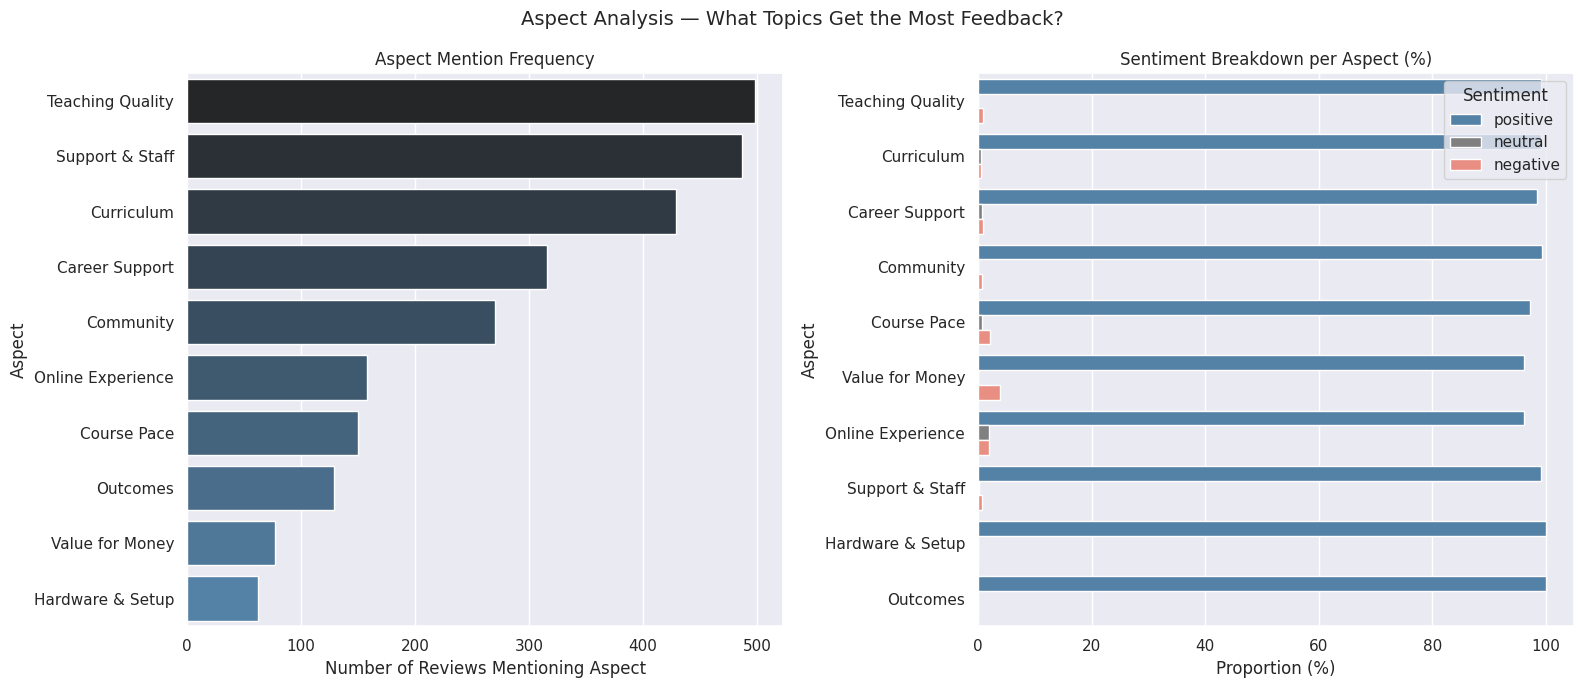

Saved: aspect_analysis.png


In [7]:
# Cell 6: Aspect Frequency Chart
# Chart 1: how often each aspect is mentioned across all reviews
# Chart 2: sentiment proportion within each aspect so we can see
#          whether mentions of each topic tend to be positive or negative

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Aspect Analysis — What Topics Get the Most Feedback?", fontsize=14)

# Chart 1: overall mention frequency
sns.barplot(
    data=aspect_df, x='count', y='aspect',
    hue='aspect', legend=False,
    ax=axes[0], palette='dark:steelblue'
)
axes[0].set_title("Aspect Mention Frequency")
axes[0].set_xlabel("Number of Reviews Mentioning Aspect")
axes[0].set_ylabel("Aspect")

# Chart 2: sentiment breakdown per aspect
sentiment_by_aspect = []
for aspect in ASPECTS:
    col    = f'aspect_{aspect}'
    subset = df[df[col] == True]
    for label in ['positive', 'neutral', 'negative']:
        count        = (subset['sentiment_label'] == label).sum()
        total_aspect = len(subset)
        proportion   = round(count / total_aspect * 100, 1) if total_aspect > 0 else 0
        sentiment_by_aspect.append({
            'aspect': aspect, 'sentiment_label': label,
            'count': count, 'proportion': proportion
        })

sentiment_aspect_df = pd.DataFrame(sentiment_by_aspect)
sentiment_aspect_df['sentiment_label'] = pd.Categorical(
    sentiment_aspect_df['sentiment_label'],
    categories=['positive', 'neutral', 'negative'], ordered=True
)
sns.barplot(
    data=sentiment_aspect_df,
    x='proportion', y='aspect',
    hue='sentiment_label',
    palette={'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'},
    ax=axes[1]
)
axes[1].set_title("Sentiment Breakdown per Aspect (%)")
axes[1].set_xlabel("Proportion (%)")
axes[1].set_ylabel("Aspect")
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'aspect_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: aspect_analysis.png")

# TF-IDF Analysis

### What is TF-IDF?

TF-IDF stands for Term Frequency - Inverse Document Frequency. It is a statistical
method for identifying which words are most important or distinctive in a particular
group of documents compared to a broader corpus.

### How does TF-IDF work?

TF-IDF combines two measurements for each word:

    Term Frequency (TF):
    How often does this word appear in this document?
    A word that appears many times in a review is likely important to that review.

    Inverse Document Frequency (IDF):
    How rare is this word across all documents in the corpus?
    A word that appears in almost every review (like "course" or "school")
    carries very little information about what makes one review different from another.
    A word that appears in only a few reviews is much more distinctive.

TF-IDF multiplies these two values together. The result is a high score for words
that appear frequently in a specific document but rarely across all documents.

### How is TF-IDF used here?

Rather than looking at individual reviews, we apply TF-IDF at the group level.
We calculate the average TF-IDF score for each word across all positive reviews,
all neutral reviews, and all negative reviews separately. We then subtract the
score of the other groups to find words that are distinctively high in one group
compared to the rest.

This reveals what language characterizes each sentiment group:

    Positive reviews: words associated with enthusiasm and satisfaction
    Neutral reviews:  words associated with balanced or factual descriptions
    Negative reviews: words associated with frustration or disappointment

### Why use TF-IDF alongside keyword matching?

Keyword matching tells us about predefined topics we already know to look for.
TF-IDF is data-driven and surfaces patterns we might not have thought to look for.
Together they give a more complete picture of what students are actually saying.

In [8]:
# TF-IDF per Sentiment Group
# Finds the most statistically distinctive words in each sentiment group
# compared to the rest of the corpus.
# TF-IDF (Term Frequency - Inverse Document Frequency) surfaces words that
# are important within a group but uncommon across all reviews.
# This reveals what language characterizes positive, neutral, and negative reviews.

TFIDF_STOPWORDS = [
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "was", "it", "i", "my", "me", "we", "our", "you",
    "your", "they", "their", "this", "that", "have", "had", "has", "be",
    "been", "are", "were", "not", "so", "as", "from", "by", "all", "very",
    "also", "more", "about", "which", "would", "could", "will", "what",
    "who", "how", "when", "there", "than", "just", "after", "during",
    "its", "if", "up", "out", "do", "did", "get", "got", "one", "can",
    "even", "really", "much", "well", "him", "her", "his", "she", "he",
    "into", "through", "while", "these", "those", "then", "only", "any",
    "each", "such", "over", "am", "wbs", "coding", "school", "bootcamp",
    "boot", "camp", "course", "program", "web", "development", "developer",
    "app", "stack", "full", "weeks", "week", "month", "months", "time",
    "class", "learn", "learned", "learning", "study", "studied",
    "experience", "highly", "recommend", "great", "good", "amazing",
    "excellent", "everything", "other", "students", "student", "thing",
    "things", "told", "instructor", "instructors", "job", "jobs", "always",
    "lot", "data", "science", "career", "new", "made", "make", "work",
    "working", "take", "took", "start", "started", "know", "like",
    "feel", "felt", "re", "ve", "ll", "didn", "don", "isn", "wasn",
    "und", "15",
]

# Fit TF-IDF on all reviews at once
all_text   = df['text_for_analysis'].fillna("").tolist()
all_labels = df['sentiment_label'].tolist()

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words=TFIDF_STOPWORDS,
    ngram_range=(1, 2),
    min_df=3,
)
tfidf_matrix = vectorizer.fit_transform(all_text)
terms        = vectorizer.get_feature_names_out()

# For each sentiment group find terms that score higher than in other groups
tfidf_results = {}
for label in ['positive', 'neutral', 'negative']:
    group_idx = [i for i, l in enumerate(all_labels) if l == label]
    rest_idx  = [i for i, l in enumerate(all_labels) if l != label]
    group_scores = np.asarray(tfidf_matrix[group_idx].mean(axis=0)).flatten()
    rest_scores  = np.asarray(tfidf_matrix[rest_idx].mean(axis=0)).flatten()
    diff = group_scores - rest_scores
    tfidf_results[label] = pd.DataFrame(
        {'term': terms, 'score': diff}
    ).nlargest(15, 'score')

print("TF-IDF terms calculated per sentiment group.")
for label, top in tfidf_results.items():
    print(f"\nTop terms for {label}:")
    print(top[['term', 'score']].to_string(index=False))

TF-IDF terms calculated per sentiment group.

Top terms for positive:
       term    score
       best 0.029665
   projects 0.024163
      staff 0.023256
 supportive 0.022741
     people 0.020383
 structured 0.020122
       help 0.019862
    support 0.018885
     skills 0.018579
 curriculum 0.017631
  community 0.017353
  knowledge 0.016993
     campus 0.016757
         us 0.016156
environment 0.016104

Top terms for neutral:
              term    score
         completed 0.084189
             place 0.067248
         completly 0.062483
          recently 0.055408
         technical 0.055286
      participated 0.051674
            hybrid 0.048551
     online campus 0.047571
              need 0.045037
recently completed 0.043785
              long 0.039989
     project based 0.039045
           quickly 0.035059
  technical skills 0.034803
             based 0.033315

Top terms for negative:
         term    score
unfortunately 0.084897
     enrolled 0.066223
         self 0.049607
     

## TF-IDF Chart

/tmp/ipykernel_799/162693493.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(
/tmp/ipykernel_799/162693493.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  sns.barplot(
/tmp/ipykernel_799/162693493.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:salmon'` for the same effect.

  sns.barplot(


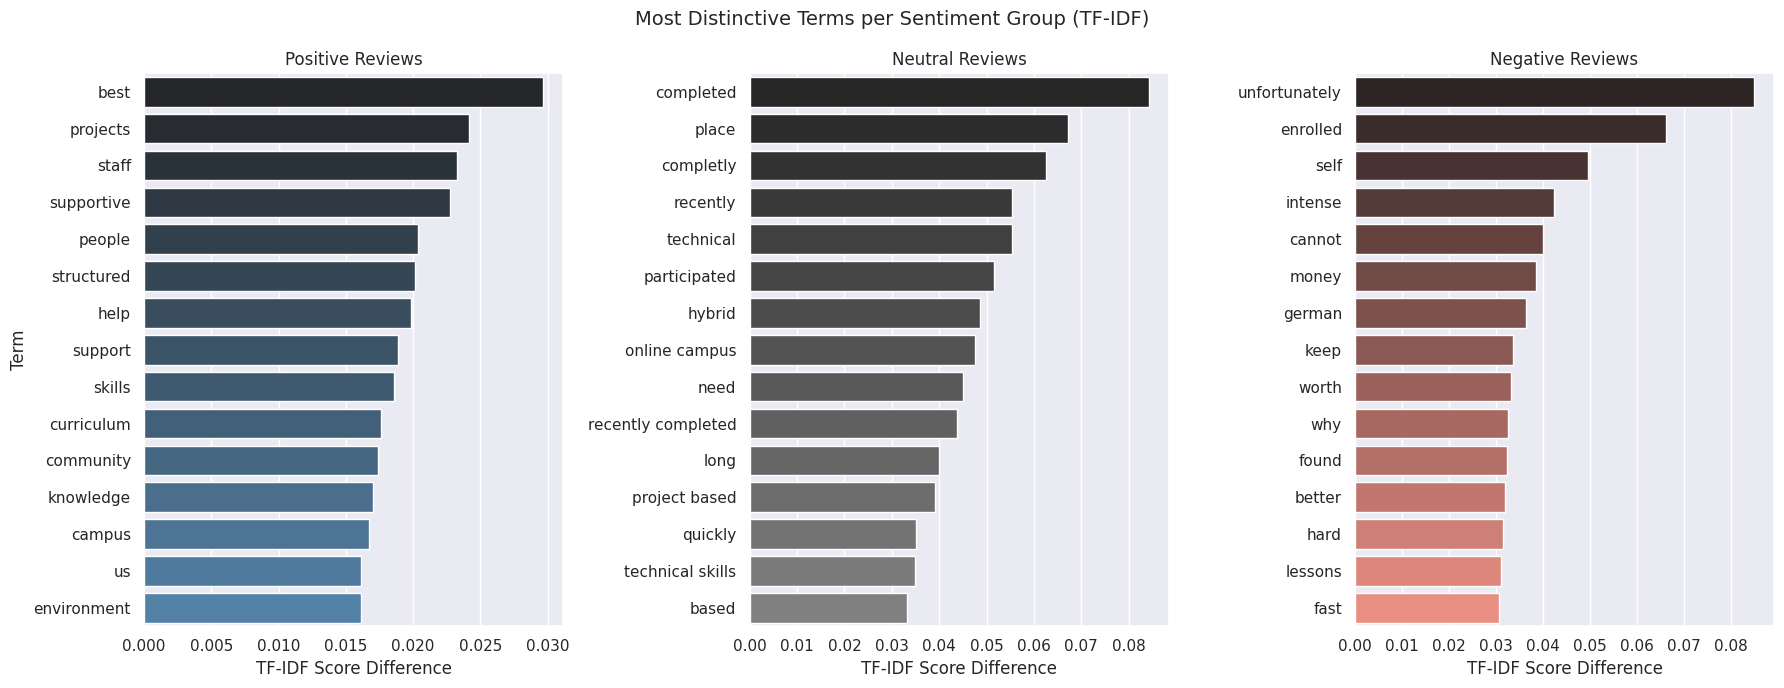

Saved: tfidf_per_sentiment.png


In [9]:
# Cell 8: TF-IDF Chart
# Visualizes the top 15 most distinctive terms per sentiment group
# side by side so we can compare what language defines each group.

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Most Distinctive Terms per Sentiment Group (TF-IDF)", fontsize=14)

colors = {'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'}

for i, label in enumerate(['positive', 'neutral', 'negative']):
    top = tfidf_results[label]
    sns.barplot(
        data=top, x='score', y='term',
        hue='term', legend=False,
        ax=axes[i], color=colors[label]
    )
    axes[i].set_title(f"{label.capitalize()} Reviews")
    axes[i].set_xlabel("TF-IDF Score Difference")
    axes[i].set_ylabel("Term" if i == 0 else "")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'tfidf_per_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tfidf_per_sentiment.png")

# Sentiment by Aspect

Now that we know which aspects are mentioned most often (Cell 5) and what language
defines each sentiment group (Cell 7), this section combines both to answer a
more specific question: when students mention each topic, are they positive or negative?

An aspect with many mentions but low average sentiment is a clear signal of a
recurring pain point. An aspect with high average sentiment is a strength worth
highlighting in marketing. The n= annotation on each bar shows how many reviews
that bar is based on so we can assess how reliable each score is.


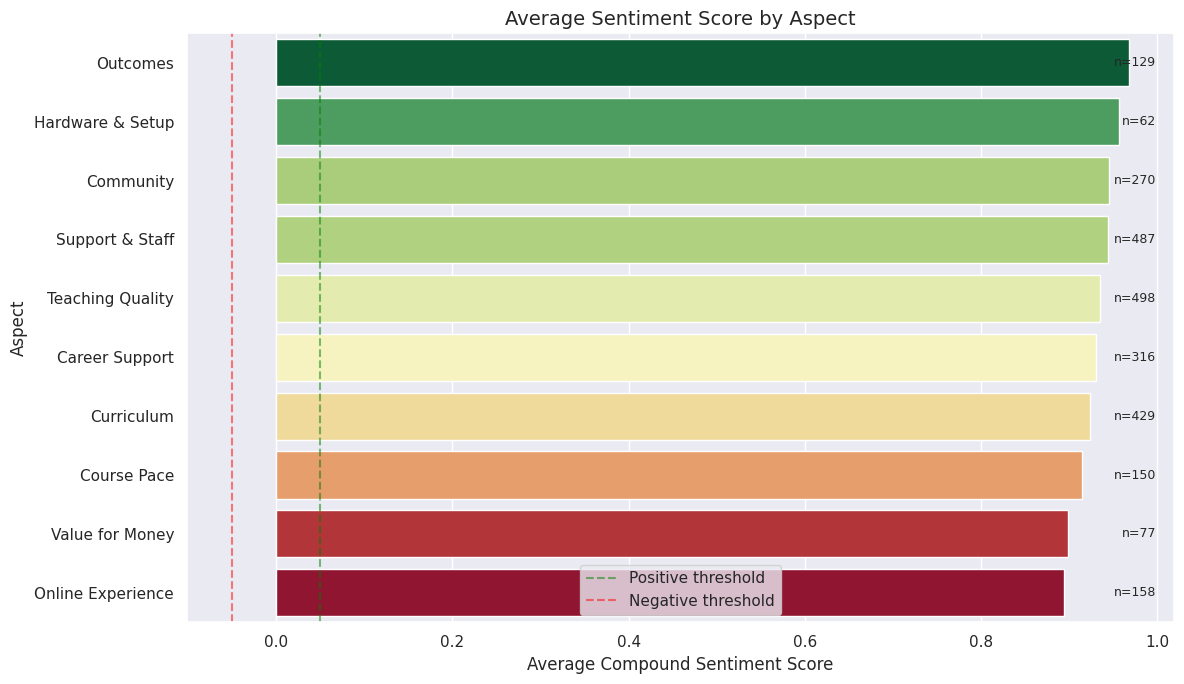

Saved: aspect_sentiment_breakdown.png

Aspect sentiment summary:
           aspect  avg_compound  mention_count
         Outcomes         0.968            129
 Hardware & Setup         0.957             62
        Community         0.945            270
  Support & Staff         0.944            487
 Teaching Quality         0.935            498
   Career Support         0.930            316
       Curriculum         0.924            429
      Course Pace         0.914            150
  Value for Money         0.899             77
Online Experience         0.894            158


In [10]:
# Aspect Sentiment Breakdown
# Shows the average compound sentiment score per aspect.
# This reveals which aspects drive positive feedback and which drive complaints.
# Only includes aspects mentioned in at least 10 reviews to ensure reliability.
# Annotated with the number of reviews per aspect for context.

aspect_sentiment = []
for aspect in ASPECTS:
    col    = f'aspect_{aspect}'
    subset = df[df[col] == True]
    if len(subset) >= 10:
        aspect_sentiment.append({
            'aspect':        aspect,
            'avg_compound':  round(subset['sentiment_compound'].mean(), 3),
            'mention_count': len(subset),
        })

aspect_sentiment_df = pd.DataFrame(aspect_sentiment).sort_values(
    'avg_compound', ascending=False
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=aspect_sentiment_df,
    x='avg_compound', y='aspect',
    hue='avg_compound', legend=False,
    ax=ax, palette='RdYlGn'
)
ax.axvline(0.05,  color='green', linestyle='--', alpha=0.5, label='Positive threshold')
ax.axvline(-0.05, color='red',   linestyle='--', alpha=0.5, label='Negative threshold')
ax.set_title("Average Sentiment Score by Aspect", fontsize=14)
ax.set_xlabel("Average Compound Sentiment Score")
ax.set_ylabel("Aspect")
ax.legend()

# Annotate bars with review counts
for i, row in aspect_sentiment_df.reset_index().iterrows():
    ax.text(
        ax.get_xlim()[1] * 0.98, i,
        f"n={row['mention_count']}",
        va='center', ha='right', fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'aspect_sentiment_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: aspect_sentiment_breakdown.png")
print("\nAspect sentiment summary:")
print(aspect_sentiment_df.to_string(index=False))

# Keywork co-occuraces

Co-occurrence analysis asks: which words tend to appear together in the same review?
When two words frequently appear together in positive reviews, it suggests they
describe a connected experience that students value.

For example, if "supportive" and "community" often appear together, that tells us
students associate a supportive atmosphere with the sense of community — a specific
message that could be used in marketing.

Each review is tokenized into its unique words (removing duplicates within a review
to avoid inflating counts) and every pair of words that appear together is counted.
The top 20 pairs are visualized. Generic words and school-specific terms are excluded
via a stopword list so only meaningful content words surface in the results.

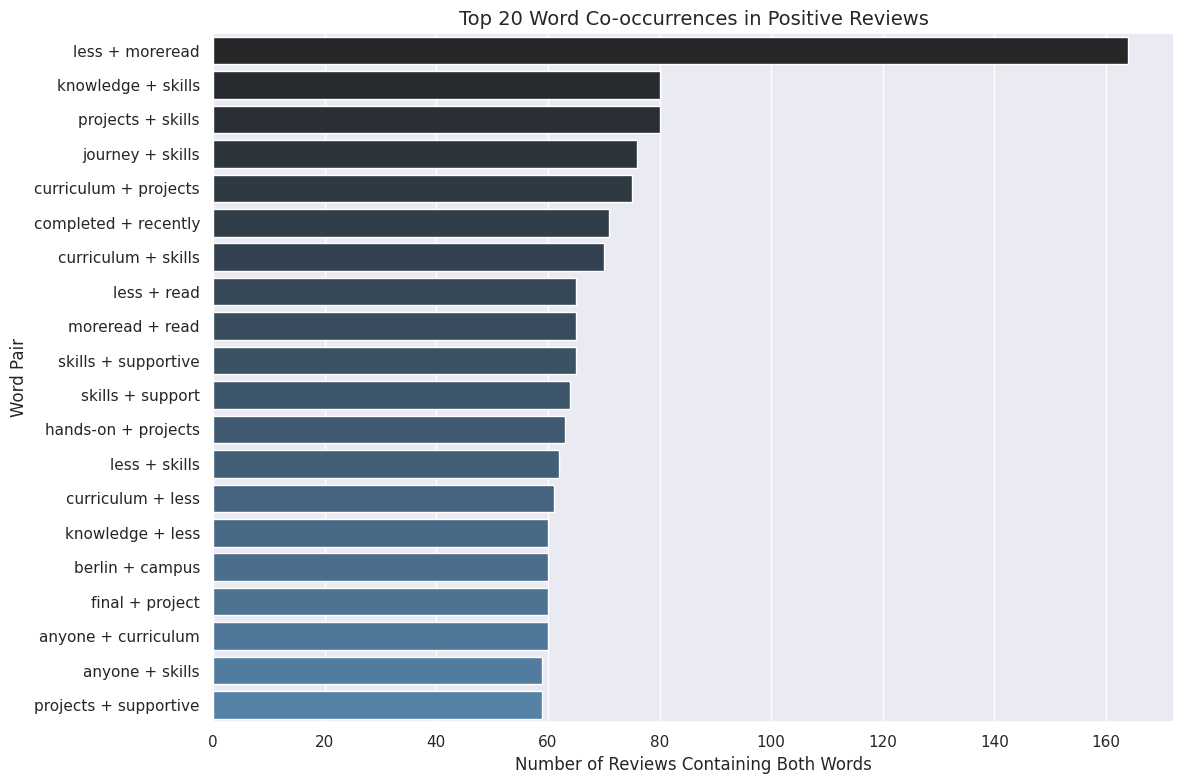

Saved: keyword_cooccurrence.png


In [11]:
# Keyword Co-occurrence in Positive Reviews
# Finds which words most commonly appear together in positive reviews.
# Each review is tokenized into unique words (duplicates removed per review)
# and every pair of words that co-occur is counted.
# The top 20 pairs reveal what concepts are most strongly associated
# with positive experiences - useful for marketing language.

COOCCUR_STOPWORDS = set(TFIDF_STOPWORDS + [
    "course", "bootcamp", "school", "wbs", "program", "week", "month",
    "learn", "learned", "work", "job", "student", "instructor", "time",
])

positive_texts = df[df['sentiment_label'] == 'positive']['text_for_analysis'].dropna()

def tokenize(text: str) -> list:
    """
    Tokenize a review into cleaned lowercase words, removing stopwords.

    Args:
        text (str): Raw review text.

    Returns:
        list: Cleaned tokens with stopwords and short words removed.
    """
    words = str(text).lower().split()
    words = [w.strip('.,!?;:"\'-()[]') for w in words]
    return [w for w in words if w not in COOCCUR_STOPWORDS and len(w) > 3]

# Count co-occurrences across all positive reviews
pair_counts = Counter()
for text in positive_texts:
    # Use unique words per review to avoid self-pairing
    words = list(set(tokenize(text)))
    for pair in combinations(sorted(words), 2):
        pair_counts[pair] += 1

top_pairs = pd.DataFrame(
    [(f"{a} + {b}", count) for (a, b), count in pair_counts.most_common(20)],
    columns=['pair', 'count']
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=top_pairs, x='count', y='pair',
    hue='pair', legend=False,
    ax=ax, palette='dark:steelblue'
)
ax.set_title("Top 20 Word Co-occurrences in Positive Reviews", fontsize=14)
ax.set_xlabel("Number of Reviews Containing Both Words")
ax.set_ylabel("Word Pair")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'keyword_cooccurrence.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: keyword_cooccurrence.png")

# Course Comparisons

This section breaks down sentiment by course to identify which programs are most
and least well received. Three complementary views are shown:

    Average score:     the mean compound sentiment score per course
    Proportion chart:  the share of positive, neutral, and negative reviews per course
    Box plot:          the full distribution of scores showing spread and outliers

The proportion chart is often more informative than the average score alone because
it shows whether a course's average is being pulled up by a few very positive reviews
or whether positivity is broadly distributed. Only courses with at least 5 reviews
are included to ensure statistical reliability.

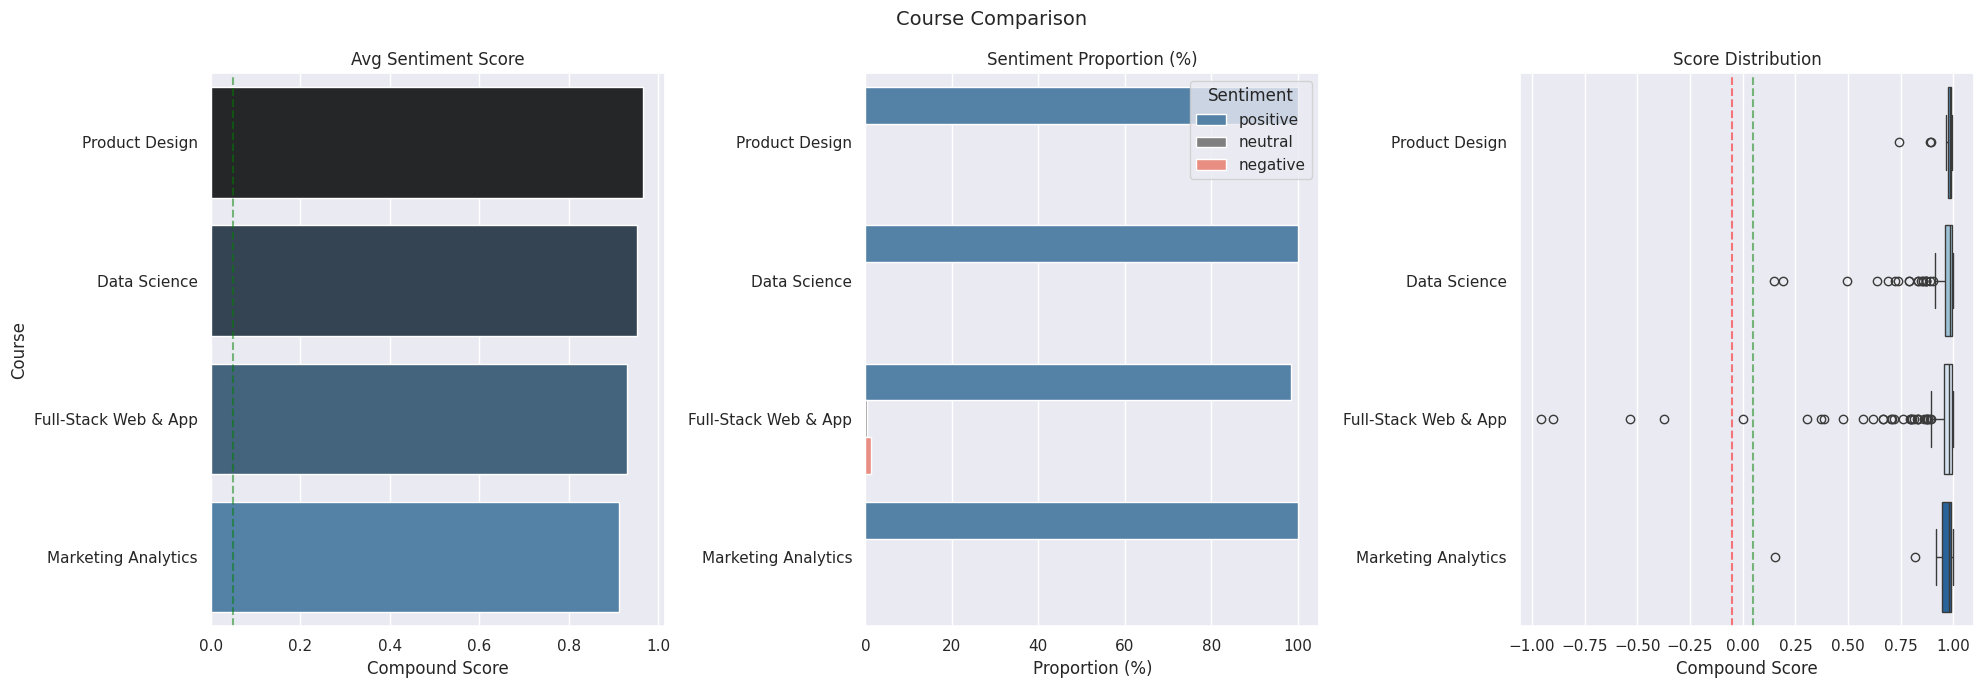

Saved: course_comparison.png

Sample sizes per course:
course
Full-Stack Web & App    314
Data Science            182
Product Design           24
Marketing Analytics      16


In [12]:
# Compares sentiment across courses using three views:
# Chart 1: average compound score per course
# Chart 2: proportion of positive/neutral/negative per course
# Chart 3: box plot showing full score distribution per course
# Only includes courses with at least 5 reviews.

course_df     = df.dropna(subset=['course']).copy()
course_counts = course_df['course'].value_counts()
valid_courses = course_counts[course_counts >= 5].index
course_df     = course_df[course_df['course'].isin(valid_courses)]

# Sort courses by median compound score for consistent ordering across charts
course_order = (
    course_df.groupby('course')['sentiment_compound']
    .median().sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Course Comparison", fontsize=14)

# Chart 1: average sentiment per course
avg_sent = course_df.groupby('course')['sentiment_compound'].mean().reset_index()
avg_sent.columns = ['course', 'avg_compound']
avg_sent = avg_sent.sort_values('avg_compound', ascending=False)
sns.barplot(
    data=avg_sent, x='avg_compound', y='course',
    hue='course', legend=False,
    ax=axes[0], palette='dark:steelblue'
)
axes[0].axvline(0.05, color='green', linestyle='--', alpha=0.5)
axes[0].set_title("Avg Sentiment Score")
axes[0].set_xlabel("Compound Score")
axes[0].set_ylabel("Course")

# Chart 2: sentiment label proportion per course
label_data = course_df.groupby(['course', 'sentiment_label']).size().reset_index(name='count')
total_data  = course_df.groupby('course').size().reset_index(name='total')
label_data  = label_data.merge(total_data, on='course')
label_data['proportion'] = (label_data['count'] / label_data['total'] * 100).round(1)
label_data['sentiment_label'] = pd.Categorical(
    label_data['sentiment_label'],
    categories=['positive', 'neutral', 'negative'], ordered=True
)
sns.barplot(
    data=label_data, x='proportion', y='course',
    hue='sentiment_label', order=course_order,
    palette={'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'},
    ax=axes[1]
)
axes[1].set_title("Sentiment Proportion (%)")
axes[1].set_xlabel("Proportion (%)")
axes[1].set_ylabel("")
axes[1].legend(title='Sentiment')

# Chart 3: box plot of full score distribution per course
sns.boxplot(
    data=course_df, x='sentiment_compound', y='course',
    hue='course', legend=False,
    order=course_order, ax=axes[2], palette='Blues'
)
axes[2].axvline(0.05,  color='green', linestyle='--', alpha=0.5)
axes[2].axvline(-0.05, color='red',   linestyle='--', alpha=0.5)
axes[2].set_title("Score Distribution")
axes[2].set_xlabel("Compound Score")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'course_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: course_comparison.png")
print("\nSample sizes per course:")
print(course_df['course'].value_counts().to_string())

# Jorney Map

Different types of reviewers may have very different experiences and expectations.
A recent graduate reflecting on how the course changed their career will write
differently from a current student halfway through the program, or from a working
developer who took a part-time course to upskill.

This section segments sentiment by reviewer role to identify whether any particular
group is consistently more positive or negative. Significant differences between
roles may indicate that the course experience varies meaningfully depending on
who is taking it and what they are hoping to get out of it.

Sample sizes per role:
role
Graduate        172
Developer        35
Student          30
Data Science     10
Manager           6
Designer          5
Other             5


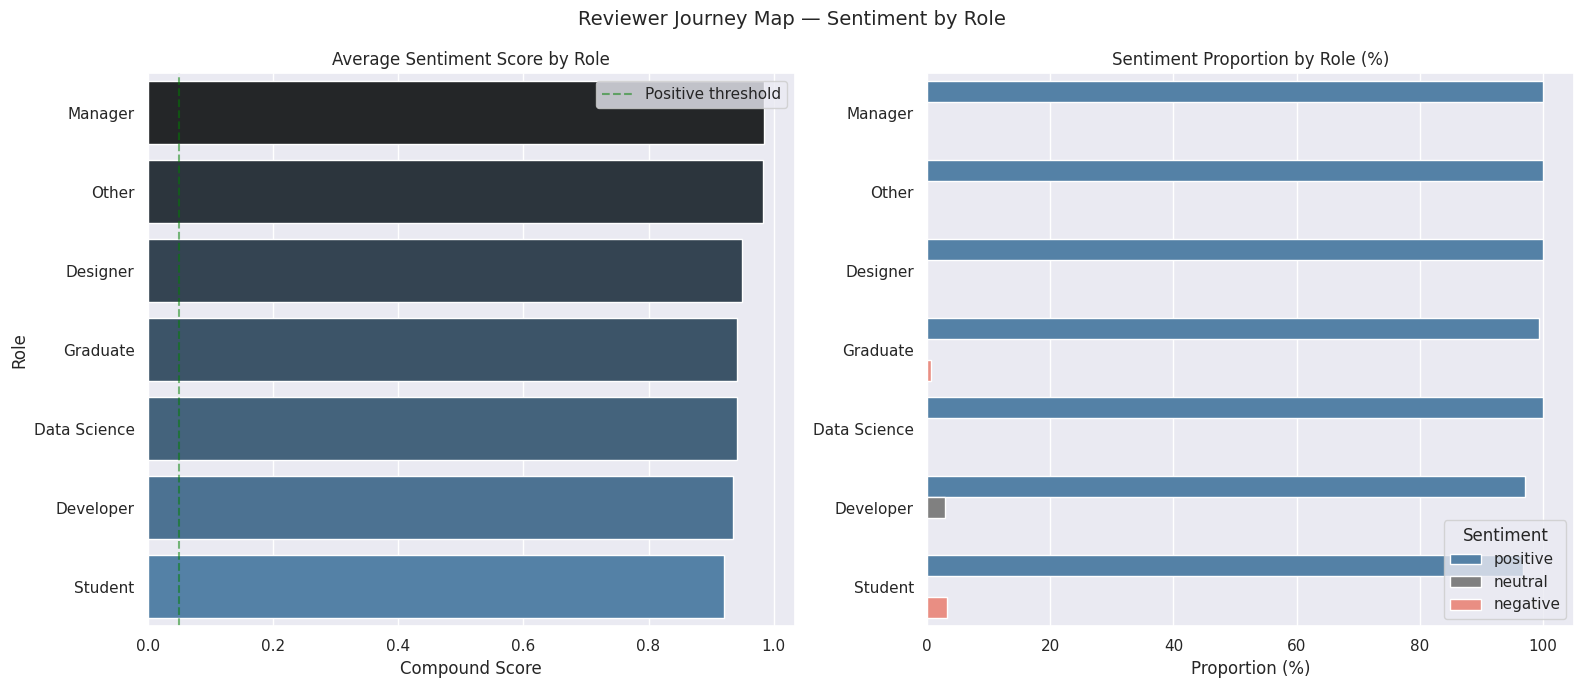

Saved: reviewer_journey_map.png


In [13]:
# Compares sentiment across reviewer roles.
# Graduates, current students, and developers may write very differently
# depending on where they are in their learning journey.
# Chart 1: average compound score per role
# Chart 2: sentiment proportion per role
# Only includes roles with at least 5 reviews.

role_df     = df.dropna(subset=['role']).copy()
role_counts = role_df['role'].value_counts()
valid_roles = role_counts[role_counts >= 5].index
role_df     = role_df[role_df['role'].isin(valid_roles)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Reviewer Journey Map — Sentiment by Role", fontsize=14)

# Chart 1: average compound score per role
avg_role = role_df.groupby('role')['sentiment_compound'].mean().reset_index()
avg_role.columns = ['role', 'avg_compound']
avg_role = avg_role.sort_values('avg_compound', ascending=False)
role_order = avg_role['role'].tolist()
sns.barplot(
    data=avg_role, x='avg_compound', y='role',
    hue='role', legend=False,
    ax=axes[0], palette='dark:steelblue'
)
axes[0].axvline(0.05, color='green', linestyle='--', alpha=0.5, label='Positive threshold')
axes[0].set_title("Average Sentiment Score by Role")
axes[0].set_xlabel("Compound Score")
axes[0].set_ylabel("Role")
axes[0].legend()

# Chart 2: sentiment proportion per role
label_data = role_df.groupby(['role', 'sentiment_label']).size().reset_index(name='count')
total_data  = role_df.groupby('role').size().reset_index(name='total')
label_data  = label_data.merge(total_data, on='role')
label_data['proportion'] = (label_data['count'] / label_data['total'] * 100).round(1)
label_data['sentiment_label'] = pd.Categorical(
    label_data['sentiment_label'],
    categories=['positive', 'neutral', 'negative'], ordered=True
)
sns.barplot(
    data=label_data, x='proportion', y='role',
    hue='sentiment_label', order=role_order,
    palette={'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'},
    ax=axes[1]
)
axes[1].set_title("Sentiment Proportion by Role (%)")
axes[1].set_xlabel("Proportion (%)")
axes[1].set_ylabel("")
axes[1].legend(title='Sentiment')

print("Sample sizes per role:")
print(role_df['role'].value_counts().to_string())

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'reviewer_journey_map.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reviewer_journey_map.png")

# Pain Point Detection

This section focuses exclusively on negative and neutral reviews to surface
recurring complaints and areas for improvement. Three approaches are combined:

    Wordcloud:        shows the most common words in negative reviews at a glance.
                      The larger the word, the more frequently it appears.

    TF-IDF comparison: finds words that are significantly more common in negative
                       reviews than in positive reviews. This surfaces language
                       that is distinctive to dissatisfied students rather than
                       just frequent in all reviews.

    Manual sample:    the 10 most negative reviews are printed in full so they
                      can be read directly. No algorithm replaces actually reading
                      what unhappy students wrote.

Total negative reviews: 14


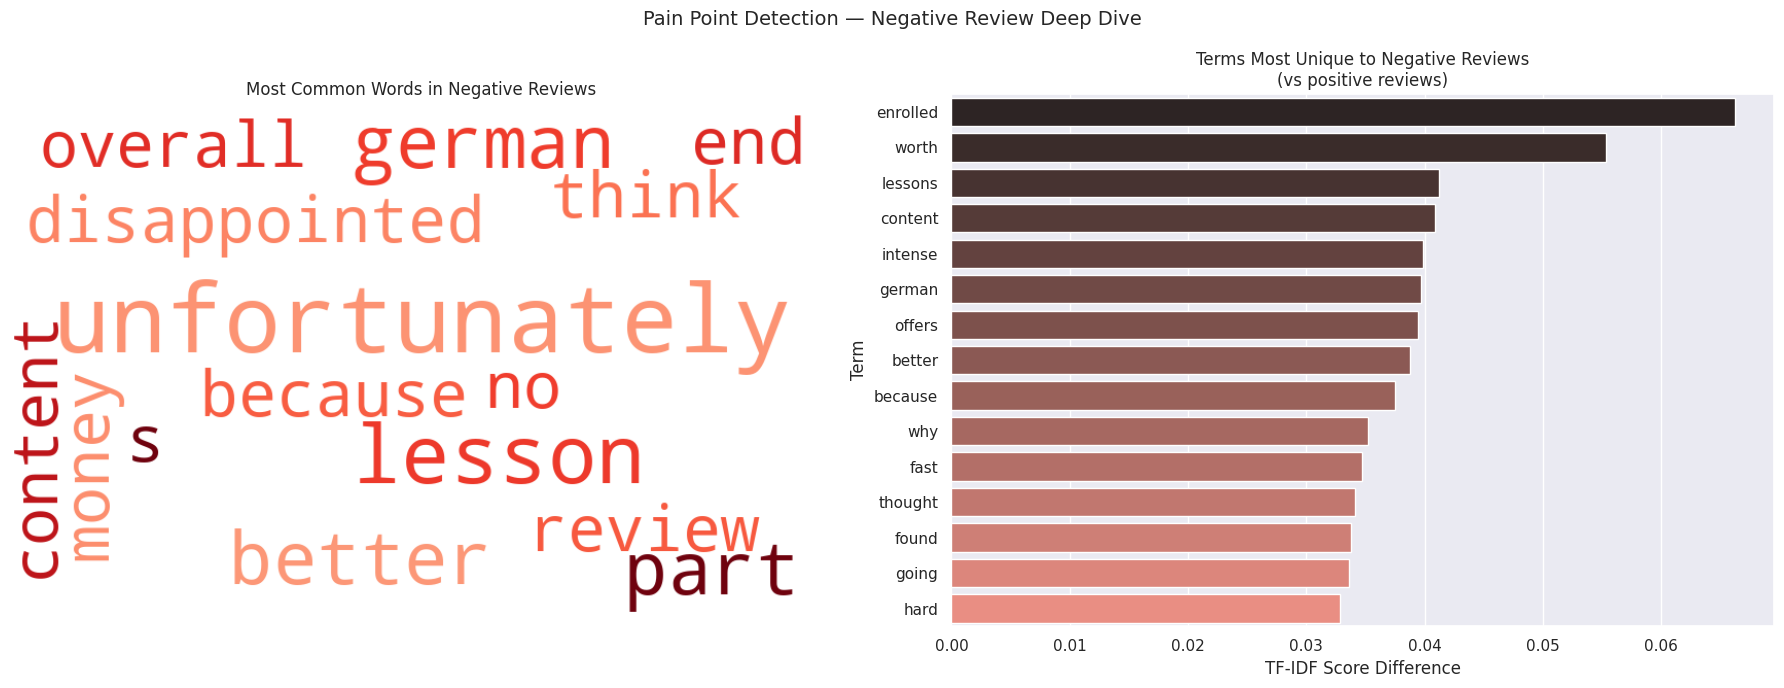

Saved: pain_point_detection.png

Top 10 most negative reviews:

[1] Anonymous | Full-Stack Web & App | Rating: 2.0 | Sentiment: -0.96
    Unfortunately disappointed overall: I attended online bootcamp full time. Unfortunately, I haven't had a good experience with WBS Coding School. Unfortunately, I can't agree with what is written here as reviews. Maybe curriculum and content of the lessons were o.k.  But overall the class instruction

[2] Anonymous | Full-Stack Web & App | Rating: 2.0 | Sentiment: -0.90
    "Disappointment": My classmates and I are really disappointed by this coding school. It feels like we could do better by watching YouTube tutorials than this coding school. It is all about one hour of unnecessary introduction, then link to the main platform, and do activities. Nothing special, no su

[3] santiago Oviedo | <NA> | Rating: 1.0 | Sentiment: -0.80
    Disappointed by Misleading Advertising and Lack of Real InstructionI enrolled in the full-stack web development bootcamp

In [14]:
# Cell 13: Pain Point Detection
# Three views of what negative reviews actually say:
# Chart 1: wordcloud of most common words in negative reviews
# Chart 2: TF-IDF terms most unique to negative vs positive reviews
# Printed: the 10 most negative reviews for manual reading

PAIN_STOPWORDS = set(TFIDF_STOPWORDS)

negative_df = df[df['sentiment_label'] == 'negative'].copy()
positive_df = df[df['sentiment_label'] == 'positive'].copy()
print(f"Total negative reviews: {len(negative_df)}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Pain Point Detection — Negative Review Deep Dive", fontsize=14)

# Chart 1: wordcloud of negative review language
negative_text = " ".join(negative_df['text_for_analysis'].str.lower().tolist())
wordcloud = WordCloud(
    width=800, height=500,
    background_color='white',
    stopwords=PAIN_STOPWORDS,
    max_words=15,
    colormap='Reds'
).generate(negative_text)
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Most Common Words in Negative Reviews")

# Chart 2: TF-IDF terms most unique to negative vs positive reviews
neg_text  = negative_df['text_for_analysis'].fillna("").tolist()
pos_text  = positive_df['text_for_analysis'].fillna("").tolist()
all_text2 = neg_text + pos_text

vectorizer2  = TfidfVectorizer(
    max_features=500,
    stop_words=list(PAIN_STOPWORDS),
    ngram_range=(1, 2),
    min_df=2,
)
tfidf2      = vectorizer2.fit_transform(all_text2)
terms2      = vectorizer2.get_feature_names_out()
neg_scores2 = np.asarray(tfidf2[:len(neg_text)].mean(axis=0)).flatten()
pos_scores2 = np.asarray(tfidf2[len(neg_text):].mean(axis=0)).flatten()
top_pain    = pd.DataFrame(
    {'term': terms2, 'diff': neg_scores2 - pos_scores2}
).nlargest(15, 'diff')

sns.barplot(
    data=top_pain, x='diff', y='term',
    hue='term', legend=False,
    ax=axes[1], palette='dark:salmon'
)
axes[1].set_title("Terms Most Unique to Negative Reviews\n(vs positive reviews)")
axes[1].set_xlabel("TF-IDF Score Difference")
axes[1].set_ylabel("Term")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'pain_point_detection.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pain_point_detection.png")

# Print most negative reviews for manual reading
print(f"\nTop 10 most negative reviews:")
print(f"{'='*80}")
most_negative = negative_df.nsmallest(10, 'sentiment_compound')[
    ['author', 'course', 'overall_experience', 'sentiment_compound', 'text_for_analysis']
].reset_index(drop=True)
for i, row in most_negative.iterrows():
    print(f"\n[{i+1}] {row['author']} | {row['course']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.2f}")
    print(f"    {str(row['text_for_analysis'])[:300]}")
    print(f"{'='*80}")

# Sentiment vs. Rating

Star ratings and written sentiment do not always agree. A reviewer might give 5 stars
but write a nuanced review that includes criticism. Another might give 3 stars but
write enthusiastically about what they learned.

These mismatches are particularly interesting for two reasons:

    High rating + negative sentiment:
    The reviewer feels obligated to rate well (perhaps socially) but their written
    words reveal genuine frustrations. These reviews are worth reading carefully
    for hidden pain points that the rating alone would mask.

    Low rating + positive sentiment:
    The reviewer writes positively but rates poorly, possibly because they had
    high expectations that were not fully met. Understanding what they valued
    despite rating poorly can inform how expectations are set during enrollment.

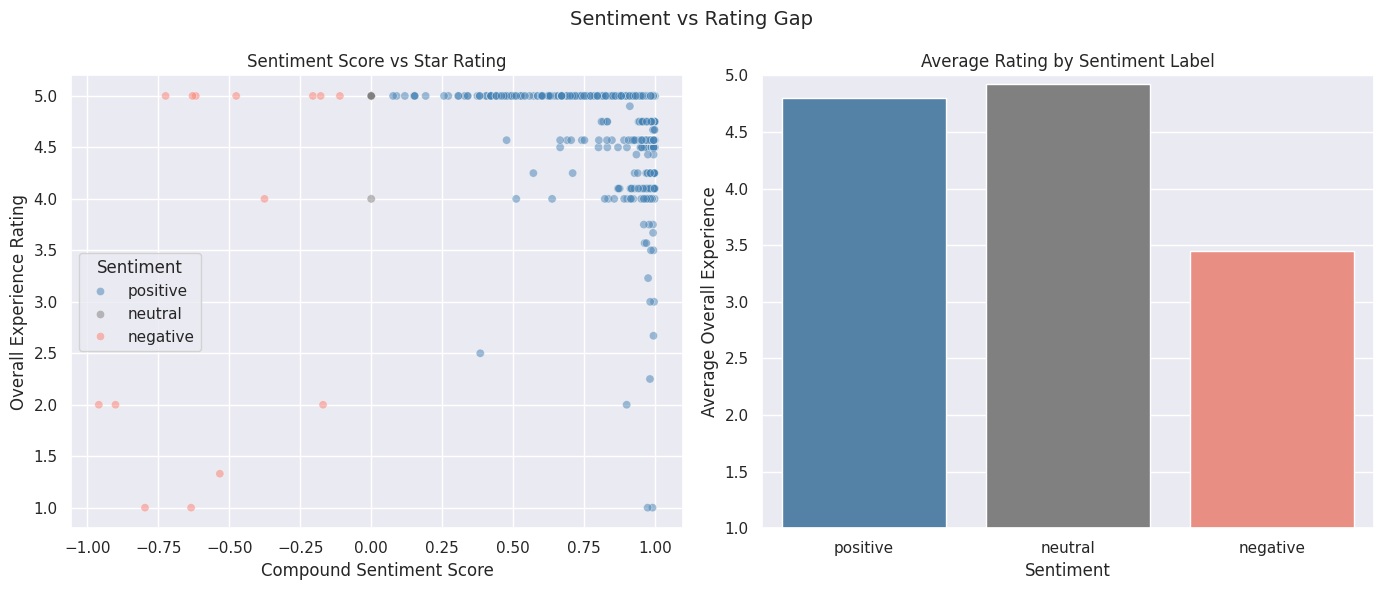

Saved: sentiment_vs_rating_gap.png

High rating (>=4) but negative sentiment:
  8 found

  Sidhdhali Nakrani | Rating: 4.0 | Sentiment: -0.38
  "Full stack web & app development": I was enrolled for the 12 week Bootcamp. I have learned a lot of things including team work , technical things , collaboration etc. if you are not native German spe

  Luise Schmidt | Rating: 5.0 | Sentiment: -0.72
  At first I was unsure whether my previous knowledge would be sufficient for the data science bootcamp - but this worry was quickly put to rest. The community managers, the entire team and fortunately 

  K. S | Rating: 5.0 | Sentiment: -0.21
  This was an incredibly intense learning experience, and it wasn't easy to keep up with everything. …

Low rating (<=2) but positive sentiment:
  3 found

  Anonymous | Rating: 1.0 | Sentiment: 0.99
  Not even worth it: After reading numerous positive reviews, I decided to start the hybrid bootcamp at the beginning of this year. The first week was okay, as e

In [15]:
# Cell 14: Sentiment vs Rating Gap
# Identifies reviews where sentiment and star rating disagree.
# High rating + negative sentiment: reviewer rates well but writes negatively
# Low rating + positive sentiment: reviewer writes positively but rates poorly
# These outliers are the most interesting for product feedback and
# can reveal nuanced issues that ratings alone would miss.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Sentiment vs Rating Gap", fontsize=14)

gap_df  = df.dropna(subset=['overall_experience', 'sentiment_compound']).copy()
palette = {'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'}

# Chart 1: scatter of compound score vs overall experience
sns.scatterplot(
    data=gap_df,
    x='sentiment_compound', y='overall_experience',
    hue='sentiment_label', palette=palette,
    alpha=0.5, ax=axes[0]
)
axes[0].set_title("Sentiment Score vs Star Rating")
axes[0].set_xlabel("Compound Sentiment Score")
axes[0].set_ylabel("Overall Experience Rating")
axes[0].legend(title='Sentiment')

# Chart 2: average rating per sentiment label
avg_rating = gap_df.groupby('sentiment_label')['overall_experience'].mean().reset_index()
sns.barplot(
    data=avg_rating,
    x='sentiment_label', y='overall_experience',
    hue='sentiment_label', legend=False,
    order=['positive', 'neutral', 'negative'],
    palette=palette, ax=axes[1]
)
axes[1].set_title("Average Rating by Sentiment Label")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Average Overall Experience")
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sentiment_vs_rating_gap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sentiment_vs_rating_gap.png")

# Print outliers
print("\nHigh rating (>=4) but negative sentiment:")
high_rate_neg = gap_df[
    (gap_df['overall_experience'] >= 4) &
    (gap_df['sentiment_label'] == 'negative')
][['author', 'course', 'overall_experience', 'sentiment_compound', 'text_for_analysis']]
print(f"  {len(high_rate_neg)} found")
for i, row in high_rate_neg.head(3).iterrows():
    print(f"\n  {row['author']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.2f}")
    print(f"  {str(row['text_for_analysis'])[:200]}")

print("\nLow rating (<=2) but positive sentiment:")
low_rate_pos = gap_df[
    (gap_df['overall_experience'] <= 2) &
    (gap_df['sentiment_label'] == 'positive')
][['author', 'course', 'overall_experience', 'sentiment_compound', 'text_for_analysis']]
print(f"  {len(low_rate_pos)} found")
for i, row in low_rate_pos.head(3).iterrows():
    print(f"\n  {row['author']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.2f}")
    print(f"  {str(row['text_for_analysis'])[:200]}")

# Time trends

This section examines whether student sentiment has been improving or declining
over time. An upward trend in compound scores suggests the course experience is
getting better. A downward trend is an early warning signal worth investigating.

Review volume varies significantly by year so each data point is annotated with
the number of reviews it represents. Years with very few reviews should be
interpreted cautiously as a single unusually positive or negative review can
skew the average significantly.

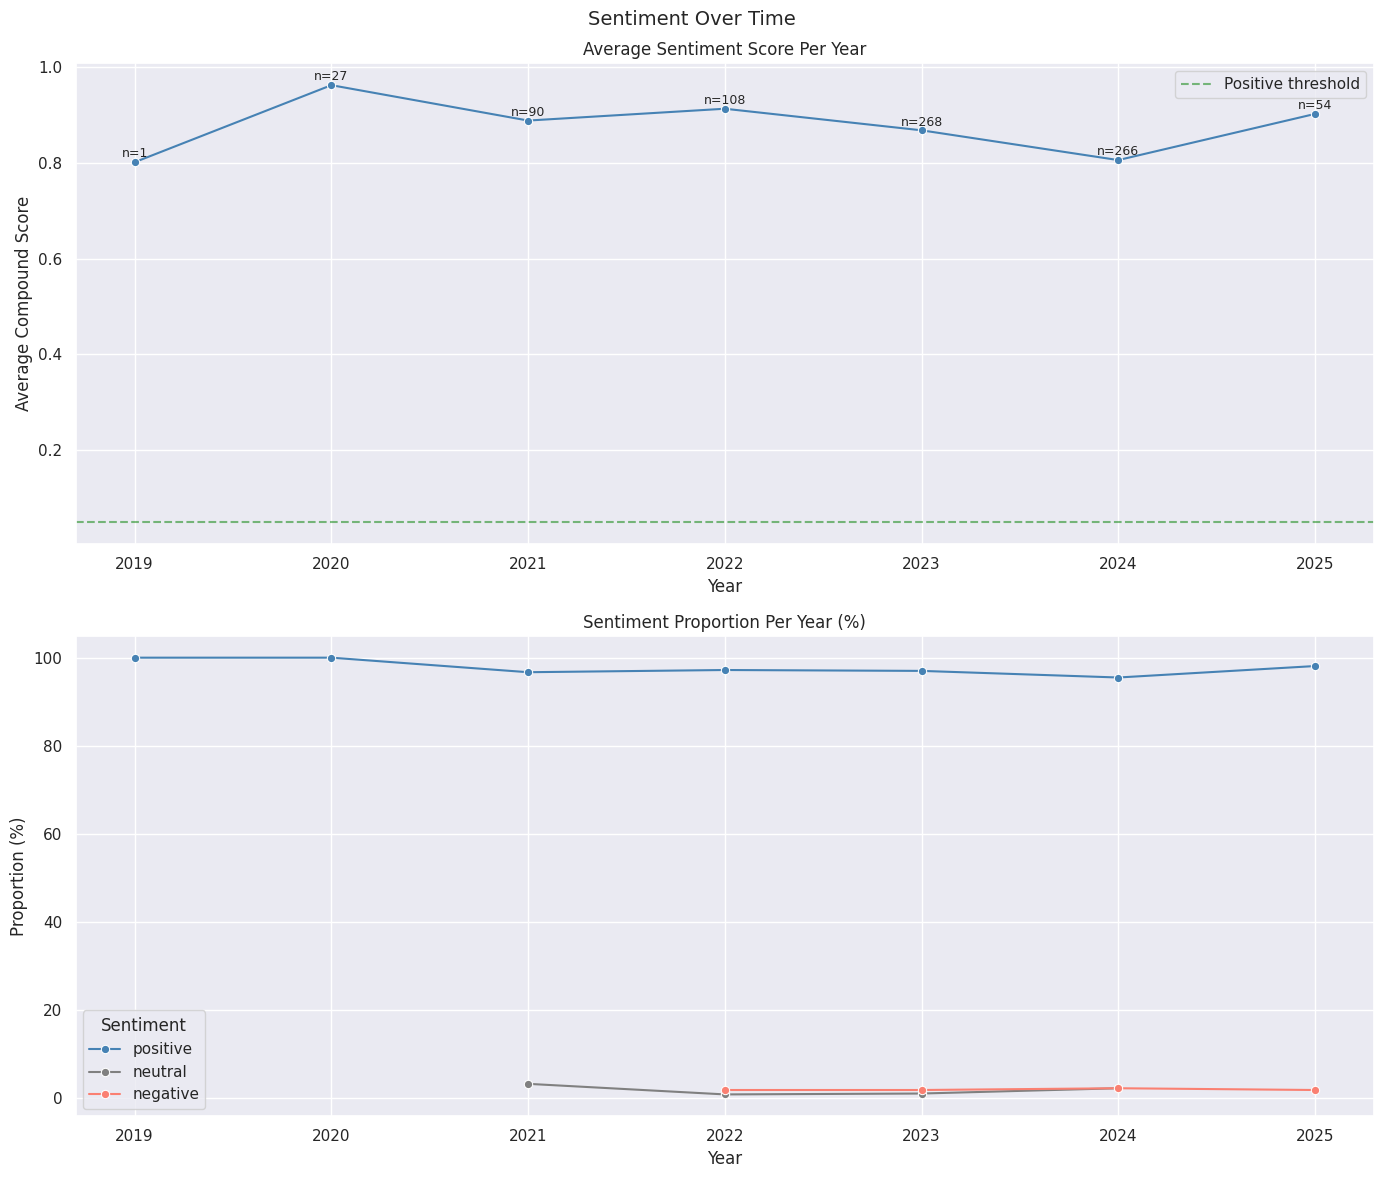

Saved: sentiment_time_trends.png


In [16]:
# Shows whether overall sentiment is improving or declining year over year.
# Chart 1: average compound score per year annotated with review counts
# Chart 2: proportion of positive/neutral/negative per year as trend lines

time_df = df.dropna(subset=['review_date']).copy()
time_df['year'] = time_df['review_date'].dt.year.astype(int)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Sentiment Over Time", fontsize=14)

# Chart 1: average compound score per year
mean_sent = time_df.groupby('year')['sentiment_compound'].mean().reset_index()
sns.lineplot(
    data=mean_sent, x='year', y='sentiment_compound',
    ax=axes[0], color='steelblue', marker='o'
)
axes[0].axhline(0.05, color='green', linestyle='--', alpha=0.5, label='Positive threshold')
axes[0].set_title("Average Sentiment Score Per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Compound Score")
axes[0].set_xticks(sorted(time_df['year'].unique()))
axes[0].legend()
for _, row in mean_sent.iterrows():
    n = len(time_df[time_df['year'] == row['year']])
    axes[0].annotate(
        f"n={n}", (row['year'], row['sentiment_compound'] + 0.01),
        ha='center', fontsize=9
    )

# Chart 2: sentiment proportion per year
label_counts = time_df.groupby(['year', 'sentiment_label']).size().reset_index(name='count')
total_year   = time_df.groupby('year').size().reset_index(name='total')
label_counts = label_counts.merge(total_year, on='year')
label_counts['proportion'] = (label_counts['count'] / label_counts['total'] * 100).round(1)
label_counts['sentiment_label'] = pd.Categorical(
    label_counts['sentiment_label'],
    categories=['positive', 'neutral', 'negative'], ordered=True
)
sns.lineplot(
    data=label_counts, x='year', y='proportion',
    hue='sentiment_label',
    palette={'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'},
    ax=axes[1], marker='o'
)
axes[1].set_title("Sentiment Proportion Per Year (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Proportion (%)")
axes[1].set_xticks(sorted(time_df['year'].unique()))
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sentiment_time_trends.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sentiment_time_trends.png")

# Marketing Quote Extraction

This section automatically identifies the best candidate reviews for use as
testimonials on the website or in marketing materials.

Candidates are filtered to reviews that are:
    - Labeled as positive sentiment by VADER
    - Rated 4.5 stars or above
    - Between 100 and 500 characters long (substantive but concise enough to use)

Candidates are then ranked by a combined score that equally weights the VADER
compound score and the star rating. The top 10% by this combined score are selected.
A shortened version of each quote (maximum 300 characters) is generated for
direct use in slides or website copy.

The original full text is always preserved in the dataset. The shortened version
is for display purposes only.

In [17]:
# Cell 16: Marketing Quote Extraction
# Automatically selects the top 10% of reviews as marketing quote candidates.
# Filters to positive sentiment, high rating, and readable length.
# Ranks candidates by a combined score of sentiment + rating.
# Shortened versions are generated for slide and website use.

MAX_QUOTE_LENGTH = 300

def shorten_quote(text: str, max_length: int) -> str:
    """
    Shorten a quote to a maximum character length without cutting mid-word.

    Args:
        text (str): Full review text.
        max_length (int): Maximum number of characters allowed.

    Returns:
        str: Shortened quote ending with ellipsis if truncated,
             or original text if already within the limit.
    """
    if len(str(text)) <= max_length:
        return str(text)
    shortened = str(text)[:max_length].rsplit(' ', 1)[0]
    return shortened + "..."

# Filter to high quality candidates
quotes_df = df[
    (df['sentiment_label'] == 'positive') &
    (df['overall_experience'] >= 4.5) &
    (df['text_for_analysis'].str.len() >= 100) &
    (df['text_for_analysis'].str.len() <= 500)
].copy()

# Score by combined sentiment + rating (both normalized to 0-1)
quotes_df['sentiment_norm'] = (
    (quotes_df['sentiment_compound'] - quotes_df['sentiment_compound'].min()) /
    (quotes_df['sentiment_compound'].max() - quotes_df['sentiment_compound'].min())
)
quotes_df['rating_norm'] = (
    (quotes_df['overall_experience'] - quotes_df['overall_experience'].min()) /
    (quotes_df['overall_experience'].max() - quotes_df['overall_experience'].min())
)
quotes_df['quote_score'] = (quotes_df['sentiment_norm'] + quotes_df['rating_norm']) / 2

# Select top 10%
top_n = max(1, int(len(quotes_df) * 0.10))
top_quotes = quotes_df.nlargest(top_n, 'quote_score').reset_index(drop=True)
top_quotes['quote_shortened'] = top_quotes['text_for_analysis'].apply(
    lambda x: shorten_quote(x, MAX_QUOTE_LENGTH)
)

print(f"Total candidates: {len(quotes_df)}")
print(f"Top 10% selected: {len(top_quotes)}")
print(f"\n{'='*80}")
for i, row in top_quotes.iterrows():
    print(f"\n[{i+1}] {row['author']} | {row['course']} | {row['role']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.2f}")
    print(f"    \"{row['quote_shortened']}\"")
    print(f"{'='*80}")

Total candidates: 348
Top 10% selected: 34


[1] Dominik Huber  | Full-Stack Web & App | Developer | Rating: 5.0 | Sentiment: 0.99
    "BEST CODING SCHOOL: Amazing experience to learn programming at WBS Coding School. The courses were well structured and I would have never thought that it's possible to learn that much content in such a short amount of time and enjoy every day of it. Super supportive and helpful group of teachers,..."

[2] julia | Product Design | <NA> | Rating: 5.0 | Sentiment: 0.99
    ""I loved it": I recently completed the Digital Product Design Bootcamp with WBS and loved it. Even tho I worked as a UX/UI Designer before I did learn so much and could deepen my skills and knowledge a lot. I gained more confidence in my decision-making and developed two cool products I am proud of..."

[3] Paul | Full-Stack Web & App | <NA> | Rating: 5.0 | Sentiment: 0.99
    ""Amazing journey!": The bootcamp was a real deep dive into web and app development, covering everything from 

# Quote Extraction

In [18]:
# Core extraction functions
#
# Instead of truncating at a fixed character limit, we now:
#   1. Split the review into individual sentences
#   2. Score each sentence with VADER
#   3. Prioritise sentences that mention getting hired or career outcomes
#   4. Select complete sentences that fit within each length band
#   5. Never cut a sentence mid-way — always return complete sentences
#
# Length bands are now defined by sentence count not character count:
#   short:  1 complete sentence (the single best sentence in the review)
#   medium: 2-3 complete sentences (the best consecutive passage)
#   long:   3-5 complete sentences (a complete thought from anywhere in the review)
#   full:   the entire review text
#
# Hiring and career outcome mentions are always prioritised over pure
# sentiment score when selecting sentences.

import re
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Keywords that indicate a career outcome mention.
# Sentences containing these are prioritised in short and medium quotes
# regardless of their VADER score.
HIRING_KEYWORDS = [
    "got a job", "found a job", "landed a job", "got hired", "been hired",
    "job offer", "employed", "working as", "now work", "currently work",
    "full time job", "started working", "new job", "new role", "new position",
    "career change", "career switch", "changed career", "hired",
    "job search", "interview", "got an offer", "accepted a position",
]


def mentions_hiring(sentence: str) -> bool:
    """
    Check whether a sentence contains any hiring or career outcome keywords.

    Args:
        sentence (str): A single sentence from a review.

    Returns:
        bool: True if any hiring keyword is found in the lowercased sentence.
    """
    lower = sentence.lower()
    return any(kw in lower for kw in HIRING_KEYWORDS)


def clean_text(text: str) -> str:
    """
    Clean review text for display and sentence splitting.
    Collapses whitespace and normalises line breaks without removing content.

    Args:
        text (str): Raw review text.

    Returns:
        str: Cleaned text suitable for sentence splitting and display.
    """
    text = str(text).strip()
    text = re.sub(r'[\r\n]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def split_sentences(text: str) -> list:
    """
    Split review text into individual complete sentences.

    Uses punctuation-based splitting while preserving sentence integrity.
    Filters out fragments under 15 characters that are not useful as quotes.
    Handles common abbreviations to avoid false splits on e.g. "Mr." or "Dr."

    Args:
        text (str): Cleaned review text.

    Returns:
        list: List of complete sentence strings.
    """
    # Temporarily protect common abbreviations from being split
    text = re.sub(r'\b(Mr|Mrs|Ms|Dr|Prof|St|vs|etc|approx|incl)\.',
                  r'\1<DOT>', text)

    # Split on sentence-ending punctuation followed by whitespace + capital
    # or end of string
    raw = re.split(r'(?<=[.!?])\s+(?=[A-Z\u201C\u2018"])', text)

    # Restore protected dots
    sentences = [s.replace('<DOT>', '.').strip() for s in raw]

    # Filter out very short fragments
    return [s for s in sentences if len(s) >= 15]


def score_sentence(sentence: str) -> float:
    """
    Score a single sentence using VADER compound score.

    Args:
        sentence (str): A single sentence.

    Returns:
        float: Compound sentiment score between -1 and +1.
    """
    return analyzer.polarity_scores(sentence)['compound']


def rank_sentences(sentences: list, sentiment_label: str) -> list:
    """
    Rank sentences by relevance for quote extraction.

    Sentences mentioning hiring or career outcomes are ranked first
    regardless of sentiment score. Remaining sentences are ranked by
    VADER score — highest for positive reviews, lowest for negative.

    Args:
        sentences (list): List of sentence strings from a review.
        sentiment_label (str): "positive" or "negative".

    Returns:
        list: Sentences sorted by relevance, most relevant first.
    """
    hiring   = [s for s in sentences if mentions_hiring(s)]
    non_hiring = [s for s in sentences if not mentions_hiring(s)]

    if sentiment_label == 'positive':
        non_hiring.sort(key=score_sentence, reverse=True)
    else:
        non_hiring.sort(key=score_sentence, reverse=False)

    return hiring + non_hiring


def extract_short_quote(text: str, sentiment_label: str) -> str:
    """
    Extract the single most impactful complete sentence as a short quote.

    Prioritises sentences mentioning hiring or career outcomes.
    Falls back to the highest scoring sentence by VADER.
    Always returns a complete sentence — never truncates mid-sentence.

    Args:
        text (str): Cleaned review text.
        sentiment_label (str): "positive" or "negative".

    Returns:
        str: One complete sentence.
    """
    sentences = split_sentences(text)
    if not sentences:
        return text

    ranked = rank_sentences(sentences, sentiment_label)
    return ranked[0]


def extract_medium_quote(text: str, sentiment_label: str) -> str:
    """
    Extract the best 2-3 complete consecutive sentences as a medium quote.

    First checks whether any hiring-related sentences exist. If so, finds
    the window of 2-3 consecutive sentences that contains the hiring
    sentence and has the highest average sentiment score.
    Otherwise selects the best consecutive 2-3 sentence window by
    average VADER score.
    Always returns complete sentences — never truncates mid-sentence.

    Args:
        text (str): Cleaned review text.
        sentiment_label (str): "positive" or "negative".

    Returns:
        str: 2-3 complete sentences joined with a space.
    """
    sentences = split_sentences(text)
    if len(sentences) == 0:
        return text
    if len(sentences) == 1:
        return sentences[0]
    if len(sentences) == 2:
        return ' '.join(sentences)

    best_window = None
    best_score  = -999 if sentiment_label == 'positive' else 999
    best_has_hiring = False

    for window_size in [2, 3]:
        for i in range(len(sentences) - window_size + 1):
            window      = sentences[i:i + window_size]
            combined    = ' '.join(window)
            has_hiring  = any(mentions_hiring(s) for s in window)
            avg_score   = float(np.mean([score_sentence(s) for s in window]))

            # Always prefer windows containing hiring mentions
            if has_hiring and not best_has_hiring:
                best_window     = combined
                best_score      = avg_score
                best_has_hiring = True
                continue

            if has_hiring == best_has_hiring:
                if sentiment_label == 'positive' and avg_score > best_score:
                    best_score  = avg_score
                    best_window = combined
                elif sentiment_label == 'negative' and avg_score < best_score:
                    best_score  = avg_score
                    best_window = combined

    return best_window if best_window else ' '.join(sentences[:2])


def extract_long_quote(text: str, sentiment_label: str) -> str:
    """
    Extract the best 3-5 complete consecutive sentences as a long quote.

    Uses the same hiring-priority logic as extract_medium_quote but
    over a larger window of 3-5 sentences. This captures a complete
    thought or narrative arc from anywhere in the review — not just
    the beginning or end.
    Always returns complete sentences — never truncates mid-sentence.

    Args:
        text (str): Cleaned review text.
        sentiment_label (str): "positive" or "negative".

    Returns:
        str: 3-5 complete sentences joined with a space.
    """
    sentences = split_sentences(text)
    if len(sentences) <= 3:
        return ' '.join(sentences)

    best_window     = None
    best_score      = -999 if sentiment_label == 'positive' else 999
    best_has_hiring = False

    for window_size in [3, 4, 5]:
        for i in range(len(sentences) - window_size + 1):
            window      = sentences[i:i + window_size]
            combined    = ' '.join(window)
            has_hiring  = any(mentions_hiring(s) for s in window)
            avg_score   = float(np.mean([score_sentence(s) for s in window]))

            if has_hiring and not best_has_hiring:
                best_window     = combined
                best_score      = avg_score
                best_has_hiring = True
                continue

            if has_hiring == best_has_hiring:
                if sentiment_label == 'positive' and avg_score > best_score:
                    best_score  = avg_score
                    best_window = combined
                elif sentiment_label == 'negative' and avg_score < best_score:
                    best_score  = avg_score
                    best_window = combined

    return best_window if best_window else ' '.join(sentences[:3])


def extract_full_quote(text: str) -> str:
    """
    Return the complete review text unchanged.
    No truncation — the full review is preserved for reference.

    Args:
        text (str): Cleaned review text.

    Returns:
        str: Complete review text.
    """
    return text


print("Quote extraction functions loaded.")
print(f"Hiring keywords tracked: {len(HIRING_KEYWORDS)}")
print("\nFunctions: extract_short_quote, extract_medium_quote, extract_long_quote, extract_full_quote")

# Quick sanity check on a sample review
sample = df['text_for_analysis'].iloc[0]
print(f"\nSample review sentences: {len(split_sentences(clean_text(sample)))}")
print(f"Short quote: {extract_short_quote(clean_text(sample), 'positive')}")

Quote extraction functions loaded.
Hiring keywords tracked: 23

Functions: extract_short_quote, extract_medium_quote, extract_long_quote, extract_full_quote

Sample review sentences: 4
Short quote: a 360 degree turn: The full-stack web development boot camp at WBS COODING SCHOOL was an intense but rewarding journey.


# Version Extraction

In [19]:
# Apply all four extraction functions to every review in the dataset.
# This creates four new columns on df:
#   quote_short   under 100 characters
#   quote_medium  100 to 250 characters
#   quote_long    250 to 500 characters
#   quote_full    complete text up to 1000 characters
#
# All quotes are extracted using sentiment-aware selection so the most
# impactful sentence or passage is always chosen for each review.

print("Cleaning text...")
df['text_clean'] = df['text_for_analysis'].apply(clean_text)

print("Extracting short quotes (under 100 chars)...")
df['quote_short'] = df.apply(
    lambda row: extract_short_quote(row['text_clean'], row['sentiment_label']),
    axis=1
)

print("Extracting medium quotes (100-250 chars)...")
df['quote_medium'] = df.apply(
    lambda row: extract_medium_quote(row['text_clean'], row['sentiment_label']),
    axis=1
)

print("Extracting long quotes (250-500 chars)...")
df['quote_long'] = df.apply(
    lambda row: extract_long_quote(row['text_clean'], row['sentiment_label']),
    axis=1
)

print("Extracting full quotes (up to 1000 chars)...")
df['quote_full'] = df['text_clean'].apply(extract_full_quote)

# Add character counts for each version so the marketing team can filter
df['len_short']  = df['quote_short'].str.len()
df['len_medium'] = df['quote_medium'].str.len()
df['len_long']   = df['quote_long'].str.len()
df['len_full']   = df['quote_full'].str.len()

print("\nExtraction complete.")
print(f"\nAvg quote lengths:")
print(f"  Short:  {df['len_short'].mean():.0f} chars")
print(f"  Medium: {df['len_medium'].mean():.0f} chars")
print(f"  Long:   {df['len_long'].mean():.0f} chars")
print(f"  Full:   {df['len_full'].mean():.0f} chars")

Cleaning text...
Extracting short quotes (under 100 chars)...
Extracting medium quotes (100-250 chars)...
Extracting long quotes (250-500 chars)...
Extracting full quotes (up to 1000 chars)...

Extraction complete.

Avg quote lengths:
  Short:  162 chars
  Medium: 292 chars
  Long:   379 chars
  Full:   803 chars


## Quote Diversity

A strong set of marketing testimonials should represent a range of students,
not just one type of reviewer. If all selected quotes come from Full-Stack Web
graduates, the marketing materials will not resonate with prospective Data Science
or Product Design students.

This step checks whether the selected quotes cover all courses and reviewer roles
that have reviews in the dataset. Any gaps are flagged with a suggestion to
adjust the selection criteria to improve diversity.

In [20]:
# Cell 17: Quote Diversity Check
# Ensures the selected marketing quotes cover a range of courses and roles.
# Flags gaps where no quote exists for a course or role that has reviews.
# A diverse quote selection is more credible and reaches a wider audience.

print("=== QUOTE DIVERSITY CHECK ===")

print("\nQuotes by course:")
print(top_quotes['course'].value_counts(dropna=False).to_string())

print("\nQuotes by role:")
print(top_quotes['role'].value_counts(dropna=False).to_string())

# Flag courses with reviews but no quotes
courses_with_reviews = df.dropna(subset=['course'])['course'].unique()
courses_with_quotes  = top_quotes.dropna(subset=['course'])['course'].unique()
missing_courses      = set(courses_with_reviews) - set(courses_with_quotes)
if missing_courses:
    print(f"\nCourses with reviews but no quotes: {missing_courses}")
    print("Consider lowering the score threshold or expanding the character limit.")
else:
    print("\nAll courses with reviews have at least one quote.")

# Flag roles with reviews but no quotes
roles_with_reviews = df.dropna(subset=['role'])['role'].unique()
roles_with_quotes  = top_quotes.dropna(subset=['role'])['role'].unique()
missing_roles      = set(roles_with_reviews) - set(roles_with_quotes)
if missing_roles:
    print(f"\nRoles with reviews but no quotes: {missing_roles}")
else:
    print("All roles with reviews have at least one quote.")

=== QUOTE DIVERSITY CHECK ===

Quotes by course:
course
Full-Stack Web & App    21
<NA>                     7
Data Science             4
Product Design           2

Quotes by role:
role
<NA>         20
Graduate      9
Developer     4
Manager       1

Courses with reviews but no quotes: {'Marketing Analytics', 'Full-Stack PHP Development'}
Consider lowering the score threshold or expanding the character limit.

Roles with reviews but no quotes: {'Data Science', 'Other', 'Applicant', 'Student', 'Designer'}


## Analysis Summary

All charts have been saved to:
    /content/drive/Shareddrives/essentis_intern_drive/charts/sentiment/

All exports have been saved to:
    /content/drive/Shareddrives/essentis_intern_drive/charts/sentiment/exports/

### Key Findings

    Most mentioned aspect:   Teaching Quality — instructors are clearly central
                             to the student experience and should be highlighted
                             in marketing.

    Most positive aspect:    Outcomes — students who discuss results and progress
                             tend to write very positively. Strong material for
                             testimonials and impact statements.

    Most negative aspect:    Online Experience — a recurring pain point worth
                             investigating. Are there specific technical or
                             platform issues driving this?

    Course to watch:         Marketing Analytics has the lowest average sentiment.
                             Reading those reviews directly (Cell 13) may reveal
                             specific issues to address.

    Sentiment over time:     Check Cell 15 for whether the trend is improving.
                             Years with fewer than 20 reviews should be treated
                             as indicative rather than conclusive.

### Important Caveats

    - VADER tends to score enthusiastic review language as strongly positive.
      The 96%+ positive rate likely overstates true satisfaction slightly.
    - Non-English reviews were machine translated before scoring. Translation
      quality may affect sentiment scores for those 40 reviews.
    - Aspect keyword matching is rule-based. Topics not covered by the keyword
      lists will not appear in the aspect analysis.

# **Semantic Search (embedding-based)**

In [21]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 63.0 MB/s eta 0:00:00


In [22]:
df.columns

Index(['batch_id', 'author', 'data_source', 'source', 'review_date',
       'overall_experience', 'review', 'instructors', 'curriculum',
       'job_assistance', 'review_text', 'review_text_translated',
       'course_format', 'course', 'role', 'verified', 'verification_source',
       'link', 'text_for_analysis', 'sentiment_pos', 'sentiment_neu',
       'sentiment_neg', 'sentiment_compound', 'sentiment_label', 'text_lower',
       'aspect_Teaching Quality', 'aspect_Curriculum', 'aspect_Career Support',
       'aspect_Community', 'aspect_Course Pace', 'aspect_Value for Money',
       'aspect_Online Experience', 'aspect_Support & Staff',
       'aspect_Hardware & Setup', 'aspect_Outcomes', 'text_clean',
       'quote_short', 'quote_medium', 'quote_long', 'quote_full', 'len_short',
       'len_medium', 'len_long', 'len_full'],
      dtype='object')

In [23]:
import faiss
from sentence_transformers import SentenceTransformer

# Create a usable text column if it does not exist

if "text" not in df.columns:
    possible_text_cols = ["review_text", "review", "review_text_translated", "text_for_analysis", "title"]
    existing_text_cols = [col for col in possible_text_cols if col in df.columns]

    if not existing_text_cols:
        raise ValueError("No suitable text column found in df.")

    df["text"] = df[existing_text_cols[0]].copy()
    for col in existing_text_cols[1:]:
        df["text"] = df["text"].fillna(df[col])

# Create analysis dataframe

search_df = df.dropna(subset=["text"]).copy()

search_df["text_clean"] = (
    search_df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

search_df = search_df[search_df["text_clean"].str.len() > 0].copy()

# Create fallback columns if some expected columns are missing

if "course" not in search_df.columns:
    search_df["course"] = pd.NA

if "course_format" not in search_df.columns:
    search_df["course_format"] = pd.NA

if "overall_experience" not in search_df.columns:
    search_df["overall_experience"] = pd.NA

if "sentiment_compound" not in search_df.columns:
    search_df["sentiment_compound"] = pd.NA

# Load embedding model

model = SentenceTransformer("all-MiniLM-L6-v2")


# Generate embeddings

emb = model.encode(
    search_df["text_clean"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

emb = np.array(emb, dtype="float32")

# Build FAISS index

index = faiss.IndexFlatIP(emb.shape[1])
index.add(emb)

# Semantic search function

def semantic_search(query, k=5):
    q = model.encode([query], normalize_embeddings=True)
    q = np.array(q, dtype="float32")

    scores, idx = index.search(q, k)

    results = search_df.iloc[idx[0]].copy()
    results["score"] = scores[0]

    return results[
        ["score", "course", "course_format", "overall_experience", "sentiment_compound", "text_clean"]
    ].rename(columns={
        "course_format": "format",
        "overall_experience": "rating",
        "sentiment_compound": "sentiment"
    })

# Semantic search with score threshold

def semantic_search_filtered(query, k=10, min_score=0.5):
    q = model.encode([query], normalize_embeddings=True)
    q = np.array(q, dtype="float32")

    scores, idx = index.search(q, k)

    results = search_df.iloc[idx[0]].copy()
    results["score"] = scores[0]
    results = results[results["score"] >= min_score]

    return results[
        ["score", "course", "course_format", "overall_experience", "sentiment_compound", "text_clean"]
    ].rename(columns={
        "course_format": "format",
        "overall_experience": "rating",
        "sentiment_compound": "sentiment"
    })


# Example searches

print("General semantic search:")
display(semantic_search("career support and job help", k=8))

print("Career support issues:")
display(semantic_search_filtered(
    "career support issues, weak job assistance, poor interview help",
    k=10,
    min_score=0.35
))

print("Positive career outcomes:")
display(semantic_search_filtered(
    "positive career outcomes, helpful job support, successful hiring experience",
    k=10,
    min_score=0.35
))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

,score,course,format,rating,sentiment,text_clean
443,0.445100,Data Science,full-time,4.57,0.9824,"""Great format and amazing teaching material"": ..."
569,0.431621,<NA>,<NA>,4.57,0.9932,"""A Challenging, Inspiring and Career-Focused B..."
630,0.405564,<NA>,<NA>,5.00,0.6705,I finished Full Stack Web & App Development Bo...
253,0.396331,Product Design,full-time,3.50,0.9849,DPD - WBS Coding School: The bootcamp served a...
574,0.395191,<NA>,<NA>,5.00,0.9886,"""WBS Coding School: An Accelerated Path to a F..."
276,0.387768,Data Science,full-time,5.00,0.9552,"""Satisfied all around! 100% recommendable!"": W..."
307,0.387209,Full-Stack Web & App,full-time,5.00,0.9885,"""One of the best decisions in my life"": Hi eve..."
23,0.385219,Full-Stack Web & App,full-time,5.00,0.9970,Amazing learning experience: I really enjoyed ...


Career support issues:


,score,course,format,rating,sentiment,text_clean


Positive career outcomes:


,score,course,format,rating,sentiment,text_clean
199,0.531514,Full-Stack Web & App,full-time,4.25,0.9842,Amazing and Valuable Experience: Really impres...
341,0.505472,Data Science,full-time,4.10,0.8689,"""Amazing Experience"": From our first contact w..."
569,0.496500,<NA>,<NA>,4.57,0.9932,"""A Challenging, Inspiring and Career-Focused B..."
810,0.472466,<NA>,<NA>,5.00,0.9099,I graduated with a sound understanding of how ...
35,0.462886,Data Science,full-time,4.50,0.8689,Amazing Experience: From our first contact wit...
815,0.456727,<NA>,<NA>,5.00,0.8261,A perfect community to learn and meet so many ...
166,0.453675,Full-Stack Web & App,full-time,4.25,0.9682,Growth and joy: I really enjoyed the different...
630,0.453099,<NA>,<NA>,5.00,0.6705,I finished Full Stack Web & App Development Bo...
80,0.447611,Full-Stack Web & App,full-time,4.75,0.9665,great time and knowledge: It’s was one of the ...
196,0.446638,Full-Stack Web & App,full-time,5.00,0.9794,The experience was extremely valuable.: This b...


### **Analysis**

* **The top matches have moderate similarity scores (~0.39–0.45), which means they are reasonably related to the query, but not extremely close matches.**

* **Most returned reviews have high ratings and very positive sentiment, so your query likely matched reviews discussing career-focused or positive support experiences.**

* **Several top results come from Data Science and Full-Stack Web & App courses, which suggests these courses contain more reviews related to your search topic.**

* **Some rows have missing course/format values (<NA>), meaning the text matched semantically, but the metadata is incomplete.**

# **Improve Semantic Search Relevance**

In [24]:
# Refine queries to target different meanings

career_support_issues = semantic_search("career support issues, weak job assistance, poor interview help", k=10)
positive_career_outcomes = semantic_search("positive career outcomes, helpful job support, successful hiring experience", k=10)

print("Career Support Issues")
display(career_support_issues)

print("Positive Career Outcomes")
display(positive_career_outcomes)

Career Support Issues


,score,course,format,rating,sentiment,text_clean
569,0.348077,<NA>,<NA>,4.57,0.9932,"""A Challenging, Inspiring and Career-Focused B..."
221,0.335974,Full-Stack Web & App,full-time,2.50,0.3840,Created unrealistic expectations: About one ye...
341,0.310680,Data Science,full-time,4.10,0.8689,"""Amazing Experience"": From our first contact w..."
37,0.304627,Full-Stack Web & App,full-time,4.50,0.9844,Totally worth it: The boot camp literally took...
443,0.301473,Data Science,full-time,4.57,0.9824,"""Great format and amazing teaching material"": ..."
35,0.300283,Data Science,full-time,4.50,0.8689,Amazing Experience: From our first contact wit...
400,0.297023,Data Science,full-time,4.10,0.9852,"""I recently completed the WBS datascience cour..."
607,0.294518,<NA>,<NA>,5.00,0.9933,"""Supportive, Structured, and Life-Changing Exp..."
141,0.294112,Data Science,full-time,4.25,0.9953,# Data Science: I embarked on a transformative...
458,0.293872,Full-Stack Web & App,full-time,5.00,0.9716,"""The best experience I had - Full-Stack Web & ..."


Positive Career Outcomes


,score,course,format,rating,sentiment,text_clean
199,0.531514,Full-Stack Web & App,full-time,4.25,0.9842,Amazing and Valuable Experience: Really impres...
341,0.505472,Data Science,full-time,4.10,0.8689,"""Amazing Experience"": From our first contact w..."
569,0.496500,<NA>,<NA>,4.57,0.9932,"""A Challenging, Inspiring and Career-Focused B..."
810,0.472466,<NA>,<NA>,5.00,0.9099,I graduated with a sound understanding of how ...
35,0.462886,Data Science,full-time,4.50,0.8689,Amazing Experience: From our first contact wit...
815,0.456727,<NA>,<NA>,5.00,0.8261,A perfect community to learn and meet so many ...
166,0.453675,Full-Stack Web & App,full-time,4.25,0.9682,Growth and joy: I really enjoyed the different...
630,0.453099,<NA>,<NA>,5.00,0.6705,I finished Full Stack Web & App Development Bo...
80,0.447611,Full-Stack Web & App,full-time,4.75,0.9665,great time and knowledge: It’s was one of the ...
196,0.446638,Full-Stack Web & App,full-time,5.00,0.9794,The experience was extremely valuable.: This b...


**Career support issues query returned weaker matches (lower scores ~0.29–0.35) and mostly positive reviews, indicating the query did not strongly capture negative experiences.

Positive career outcomes query performed better (higher scores ~0.45–0.53) and consistently returned high-rated, positive reviews, showing the model captures positive career-related themes more effectively.

👉 Overall: The search works better for positive queries, while negative/issue-based queries need refinement to retrieve more relevant complaint-focused results.

**Apply a similarity score threshold to filter weaker matches**

In [25]:
def semantic_search_filtered(query, k=10, min_score=0.5):
    q = model.encode([query], normalize_embeddings=True)
    q = np.array(q, dtype="float32")

    scores, idx = index.search(q, k)

    results = search_df.iloc[idx[0]].copy()
    results["score"] = scores[0]

    results = results[results["score"] >= min_score]

    return results[
        ["score", "course", "course_format", "overall_experience", "sentiment_compound", "text_clean"]
    ].rename(columns={
        "course_format": "format",
        "overall_experience": "rating",
        "sentiment_compound": "sentiment"
    })

# Example usage
filtered_issues = semantic_search_filtered(
    "career support issues, weak job assistance, poor interview help",
    k=10,
    min_score=0.5
)

filtered_positive = semantic_search_filtered(
    "positive career outcomes, helpful job support, successful hiring experience",
    k=10,
    min_score=0.5
)

print("Filtered Career Support Issues")
display(filtered_issues)

print("Filtered Positive Career Outcomes")
display(filtered_positive)

Filtered Career Support Issues


,score,course,format,rating,sentiment,text_clean


Filtered Positive Career Outcomes


,score,course,format,rating,sentiment,text_clean
199,0.531514,Full-Stack Web & App,full-time,4.25,0.9842,Amazing and Valuable Experience: Really impres...
341,0.505472,Data Science,full-time,4.10,0.8689,"""Amazing Experience"": From our first contact w..."


### **Analysis**

* **The career support issues query returned low similarity scores and no strong matches after applying the threshold, indicating that negative career-related feedback is either limited or not well captured by the current query.**

* **In contrast, the positive career outcomes query produced higher similarity scores (≥0.5) and retained strong matches, confirming that career-related discussions in the dataset are predominantly positive and well-represented, especially in Full-Stack and Data Science courses.**

**Conclusion**

* **Semantic search is more effective for positive themes, while negative issue detection requires better query refinement and more negative data.**

# **Product and Support team**

In [26]:
# Product team -> investigate weak areas (e.g., career support complaints)


product_issues = df[
    (df["overall_experience"] <= 2.5) &
    (df["text"].notna())
].copy()

product_issues["text_clean"] = (
    product_issues["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Search specifically for career support complaints
career_support_issues = semantic_search_filtered(
    "career support problems, poor job assistance, weak interview support, no hiring help",
    k=20,
    min_score=0.10
)

career_support_issues.head(10)

,score,course,format,rating,sentiment,text_clean
569,0.320803,<NA>,<NA>,4.57,0.9932,"""A Challenging, Inspiring and Career-Focused B..."
221,0.309518,Full-Stack Web & App,full-time,2.50,0.3840,Created unrealistic expectations: About one ye...
690,0.301912,<NA>,<NA>,5.00,-0.6177,I was having difficulties to find a job in Ger...
341,0.269823,Data Science,full-time,4.10,0.8689,"""Amazing Experience"": From our first contact w..."
141,0.268456,Data Science,full-time,4.25,0.9953,# Data Science: I embarked on a transformative...
630,0.267564,<NA>,<NA>,5.00,0.6705,I finished Full Stack Web & App Development Bo...
35,0.267440,Data Science,full-time,4.50,0.8689,Amazing Experience: From our first contact wit...
458,0.267371,Full-Stack Web & App,full-time,5.00,0.9716,"""The best experience I had - Full-Stack Web & ..."
307,0.261221,Full-Stack Web & App,full-time,5.00,0.9885,"""One of the best decisions in my life"": Hi eve..."
443,0.257126,Data Science,full-time,4.57,0.9824,"""Great format and amazing teaching material"": ..."


## **Analysis**

* **The negative reviews highlight weak career support, including basic or unhelpful advice, unrealistic job expectations, and lack of practical guidance for job placement**

* **They also indicate insufficient support during challenging periods (e.g., burnout, overwhelm), suggesting gaps in both career services and student support systems.**

In [27]:
# =============================================================================
# TEACHING QUALITY
# =============================================================================
print("=" * 60)
print("TEACHING QUALITY — General")
display(semantic_search("instructor quality and teaching experience", k=8))

print("Teaching Quality — Positive:")
display(semantic_search_filtered(
    "excellent instructor supportive mentor clear explanation engaging teaching",
    k=10, min_score=0.35
))

print("Teaching Quality — Negative:")
display(semantic_search_filtered(
    "poor instructor unhelpful teacher bad explanation confusing lessons",
    k=10, min_score=0.30
))

# =============================================================================
# CURRICULUM AND CONTENT
# =============================================================================
print("=" * 60)
print("CURRICULUM — General")
display(semantic_search("curriculum content and course material quality", k=8))

print("Curriculum — Positive:")
display(semantic_search_filtered(
    "strong curriculum practical projects relevant content up to date material",
    k=10, min_score=0.35
))

print("Curriculum — Negative:")
display(semantic_search_filtered(
    "outdated curriculum irrelevant content poor course structure weak material",
    k=10, min_score=0.30
))

# =============================================================================
# COMMUNITY AND PEERS
# =============================================================================
print("=" * 60)
print("COMMUNITY — General")
display(semantic_search("student community peers and cohort experience", k=8))

print("Community — Positive:")
display(semantic_search_filtered(
    "amazing community supportive peers motivated cohort great atmosphere",
    k=10, min_score=0.35
))

print("Community — Negative:")
display(semantic_search_filtered(
    "isolated no community poor group dynamics lack of peer support",
    k=10, min_score=0.30
))

# =============================================================================
# WORKLOAD AND PACE
# =============================================================================
print("=" * 60)
print("WORKLOAD — General")
display(semantic_search("course workload pace and intensity", k=8))

print("Workload — Manageable:")
display(semantic_search_filtered(
    "well paced manageable workload clear structure balanced intensity",
    k=10, min_score=0.35
))

print("Workload — Overwhelming:")
display(semantic_search_filtered(
    "overwhelming workload too fast too intense burnout exhausting too much",
    k=10, min_score=0.30
))

# =============================================================================
# VALUE FOR MONEY
# =============================================================================
print("=" * 60)
print("VALUE FOR MONEY — General")
display(semantic_search("course price cost and value for money", k=8))

print("Value — Worth it:")
display(semantic_search_filtered(
    "worth the money great investment good value affordable well worth it",
    k=10, min_score=0.35
))

print("Value — Not worth it:")
display(semantic_search_filtered(
    "too expensive not worth the price overpriced poor value waste of money",
    k=10, min_score=0.30
))

# =============================================================================
# ONLINE AND TECHNICAL EXPERIENCE
# =============================================================================
print("=" * 60)
print("ONLINE EXPERIENCE — General")
display(semantic_search("online learning platform and remote experience", k=8))

print("Online — Positive:")
display(semantic_search_filtered(
    "great online experience smooth platform easy to use remote learning works well",
    k=10, min_score=0.35
))

print("Online — Negative:")
display(semantic_search_filtered(
    "technical issues poor platform bad connection online problems zoom difficulties",
    k=10, min_score=0.30
))

# =============================================================================
# CAREER CHANGE AND LIFE IMPACT
# =============================================================================
print("=" * 60)
print("CAREER CHANGE — General")
display(semantic_search("career change life transformation new direction", k=8))

print("Career Change — Life changing:")
display(semantic_search_filtered(
    "changed my life new career path transformed life direction best decision",
    k=10, min_score=0.35
))

print("Career Change — Unmet expectations:")
display(semantic_search_filtered(
    "did not help career no job support misleading promises not what expected",
    k=10, min_score=0.30
))

# =============================================================================
# SUPPORT AND STAFF
# =============================================================================
print("=" * 60)
print("SUPPORT AND STAFF — General")
display(semantic_search("staff support team helpfulness and communication", k=8))

print("Support — Positive:")
display(semantic_search_filtered(
    "helpful staff excellent support responsive team great communication always available",
    k=10, min_score=0.35
))

print("Support — Negative:")
display(semantic_search_filtered(
    "unresponsive staff poor support no help slow communication ignored",
    k=10, min_score=0.30
))

# =============================================================================
# BEGINNER FRIENDLINESS
# =============================================================================
print("=" * 60)
print("BEGINNER FRIENDLINESS — General")
display(semantic_search("prior experience required beginner friendly entry level", k=8))

print("Beginner Friendly — Positive:")
display(semantic_search_filtered(
    "no prior experience needed beginner friendly accessible to everyone easy to start",
    k=10, min_score=0.35
))

print("Beginner Friendly — Negative:")
display(semantic_search_filtered(
    "too advanced for beginners assumed knowledge not suitable for beginners prerequisite",
    k=10, min_score=0.30
))

# =============================================================================
# OUTCOMES AND RESULTS
# =============================================================================
print("=" * 60)
print("OUTCOMES — General")
display(semantic_search("course outcomes results skills gained after bootcamp", k=8))

print("Outcomes — Strong skills gained:")
display(semantic_search_filtered(
    "learned a lot gained new skills confident developer ready for industry",
    k=10, min_score=0.35
))

print("Outcomes — Skills gap:")
display(semantic_search_filtered(
    "did not learn enough skill gap not job ready unprepared for real work",
    k=10, min_score=0.30
))

# =============================================================================
# RECOMMENDATION
# =============================================================================
print("=" * 60)
print("RECOMMENDATION — General")
display(semantic_search("would recommend to others worth doing", k=8))

print("Recommendation — Strongly recommend:")
display(semantic_search_filtered(
    "highly recommend to everyone best bootcamp great choice would do it again",
    k=10, min_score=0.35
))

print("Recommendation — Would not recommend:")
display(semantic_search_filtered(
    "would not recommend disappointing poor experience not worth it avoid",
    k=10, min_score=0.30
))

# =============================================================================
# MARKETING GOLD — USP LANGUAGE
# =============================================================================
print("=" * 60)
print("USP LANGUAGE — General")
display(semantic_search("unique selling point best school compared to others", k=8))

print("USP — Explicit comparison to other schools:")
display(semantic_search_filtered(
    "better than other schools compared to alternatives only place best bootcamp out there",
    k=10, min_score=0.30
))

print("USP — Life impact quotes (best for marketing):")
display(semantic_search_filtered(
    "changed my life gave me a new direction foundation new career best investment I ever made",
    k=10, min_score=0.35
))

TEACHING QUALITY — General


,score,course,format,rating,sentiment,text_clean
293,0.600569,Full-Stack Web & App,full-time,5.00,0.9758,"""Excellent instructor great team"": It’s was on..."
364,0.591951,Full-Stack Web & App,full-time,4.10,0.9485,"""Professional Full-Time Training Experience"": ..."
513,0.587422,Full-Stack Web & App,full-time,4.57,0.9552,"""Good experience."": The supportive and engagin..."
518,0.571938,Full-Stack Web & App,<NA>,5.00,0.9485,"""Amazing journey"": Spending time learning so m..."
321,0.570420,Full-Stack Web & App,full-time,1.33,-0.5330,"not that good: Lectures , lessons are not that..."
500,0.567984,Full-Stack Web & App,full-time,5.00,0.9586,"""Awesome experience"": Excellent instructor, am..."
315,0.566097,Full-Stack Web & App,full-time,4.57,0.9637,"""Intense and totally worth it"": My class membe..."
256,0.563838,Full-Stack Web & App,full-time,2.25,0.9814,Disappointing Quality: I have been attending t...


Teaching Quality — Positive:


,score,course,format,rating,sentiment,text_clean
513,0.632183,Full-Stack Web & App,full-time,4.57,0.9552,"""Good experience."": The supportive and engagin..."
500,0.603011,Full-Stack Web & App,full-time,5.00,0.9586,"""Awesome experience"": Excellent instructor, am..."
518,0.575989,Full-Stack Web & App,<NA>,5.00,0.9485,"""Amazing journey"": Spending time learning so m..."
442,0.572882,Full-Stack Web & App,full-time,5.00,0.9449,"""The instructors were one of the best parts of..."
293,0.562335,Full-Stack Web & App,full-time,5.00,0.9758,"""Excellent instructor great team"": It’s was on..."
403,0.555464,Full-Stack Web & App,full-time,5.00,0.9953,"""teacher knows how to explain!"": A few years a..."
315,0.551239,Full-Stack Web & App,full-time,4.57,0.9637,"""Intense and totally worth it"": My class membe..."
638,0.532998,<NA>,<NA>,5.00,0.5267,passionate instructors and team
282,0.521857,Full-Stack Web & App,full-time,4.10,0.9921,"""A review from a graduate"": What to say about ..."
272,0.518903,Data Science,full-time,5.00,0.9913,"""Very nice setup with highly motivated and kno..."


Teaching Quality — Negative:


...

,score,course,format,rating,sentiment,text_clean
646,0.551404,<NA>,<NA>,5.0,0.9246,"Great school, great instructors & suppot staff..."
463,0.534888,Data Science,full-time,4.1,0.9767,"""PERFECT"": one of the best experiance for me, ..."
648,0.478005,<NA>,<NA>,5.0,0.8625,I 'd give a double five star for this amazing ...
170,0.456683,Full-Stack Web & App,full-time,5.0,0.9919,BEST CODING SCHOOL: Amazing experience to lear...
492,0.450856,Marketing Analytics,full-time,4.0,0.9823,"""Great place to learn"": I was particularly imp..."
473,0.449810,Marketing Analytics,full-time,5.0,0.9876,"""Top Marketing Analytics Bootcamp!"": Top Marke..."
64,0.447881,Full-Stack Web & App,full-time,5.0,0.9824,AMAZING: All I can say is if you want to learn...
810,0.442412,<NA>,<NA>,5.0,0.9099,I graduated with a sound understanding of how ...


USP — Explicit comparison to other schools:


,score,course,format,rating,sentiment,text_clean
622,0.716219,<NA>,<NA>,5.00,0.8364,Attending the WBS Bootcamp has been one of the...
325,0.688625,Full-Stack Web & App,full-time,4.00,0.9226,"""Not regret to choose this bootcamp!"": Pros: U..."
431,0.670881,Data Science,full-time,4.57,0.9655,"""WBS Coding School, The Best"": The best bootca..."
662,0.669051,<NA>,<NA>,5.00,0.7717,Its an amazing place to upskill your knowledge...
208,0.668898,Full-Stack Web & App,full-time,5.00,0.9677,The best bootcamp: I have taken the 15-week lo...
712,0.658463,<NA>,<NA>,5.00,0.8548,Tt's a MUST! This experience has been incredib...
636,0.656991,<NA>,<NA>,5.00,0.9259,The 15-week Bootcamp I attended was amazing. T...
19,0.654650,Full-Stack Web & App,full-time,5.00,0.9506,Life changing Bootcamp: If you want to improve...
133,0.652961,Full-Stack Web & App,full-time,4.50,0.8313,Professional Full-Time Training Experience: Bo...
553,0.650571,Full-Stack Web & App,<NA>,5.00,0.9412,"""The best bootcamp"": I have taken the 15-week ..."


USP — Life impact quotes (best for marketing):


,score,course,format,rating,sentiment,text_clean
809,0.452742,<NA>,<NA>,5.00,0.7960,I just finished the Full Stack Developer cours...
794,0.427373,<NA>,<NA>,5.00,0.8805,I recently graduated from the Data Science Boo...
80,0.426615,Full-Stack Web & App,full-time,4.75,0.9665,great time and knowledge: It’s was one of the ...
536,0.423307,<NA>,full-time,5.00,0.9917,"""A Truly Impactful Experience – Beyond Just AI..."
672,0.412569,<NA>,<NA>,5.00,0.8057,If you want to improve your skills and start n...
713,0.411552,<NA>,<NA>,5.00,0.6900,Starting my data science journey at WBS coding...
422,0.408693,Full-Stack Web & App,full-time,4.57,0.4767,"""Breathe taking Experience that has transforme..."
556,0.407814,<NA>,<NA>,5.00,0.9802,"""All you need to change your life is here"": I'..."
200,0.405585,Data Science,full-time,5.00,0.9979,15 weeks of expansion!: A life-changing experi...
132,0.404439,Full-Stack Web & App,full-time,5.00,0.9538,Web and App Development: This was the best dec...


## Exports

In [28]:
# Merge quote columns from df onto top_quotes before exporting.
# top_quotes was built before the new extraction columns existed so
# we join them back on author + review_text.

quote_cols = ['author', 'review_text', 'quote_short', 'quote_medium', 'quote_long']

# Only proceed if the quote columns exist on df
if 'quote_short' in df.columns:
    merge_quotes = df[quote_cols].drop_duplicates(subset=['author', 'review_text'])
    top_quotes = top_quotes.merge(
        merge_quotes,
        on=['author', 'review_text'],
        how='left'
    )
    print(f"Quote columns merged onto top_quotes. Shape: {top_quotes.shape}")
else:
    print("WARNING: quote columns not found on df.")
    print("Make sure you have run the marketing quotes notebook Cell 3 and Cell 4 first.")
    print("Then re-run this cell.")

Quote columns merged onto top_quotes. Shape: (34, 42)


In [29]:
# Export marketing quotes and sentiment summary to CSV.
# Uses the new multi-length quote columns from the revised extraction approach.
# quote_short, quote_medium, and quote_long are complete sentences —
# never truncated mid-way. Hiring mentions are prioritised in selection.

slide_table = top_quotes[[
    'author', 'course', 'role',
    'overall_experience', 'sentiment_compound',
    'quote_short', 'quote_medium', 'quote_long',
]].rename(columns={
    'author':             'Reviewer',
    'course':             'Course',
    'role':               'Role',
    'overall_experience': 'Rating',
    'sentiment_compound': 'Sentiment Score',
    'quote_short':        'Quote (Short)',
    'quote_medium':       'Quote (Medium)',
    'quote_long':         'Quote (Long)',
})

quotes_path = os.path.join(EXPORT_DIR, 'marketing_quotes.csv')
slide_table.to_csv(quotes_path, index=False)

print(f"Saved: marketing_quotes.csv ({len(slide_table)} quotes)")
print(f"\nPreview (first 3 rows):")
for i, row in slide_table.head(3).iterrows():
    print(f"\n  [{i+1}] {row['Reviewer']} | {row['Course']} | {row['Rating']} stars")
    print(f"  SHORT:  {row['Quote (Short)']}")
    print(f"  MEDIUM: {row['Quote (Medium)']}")
    print(f"  LONG:   {row['Quote (Long)'][:120]}...")

# Build and save sentiment summary
summary = {
    "total_reviews_analyzed":  [len(df)],
    "reviews_translated":      [df['review_text_translated'].notna().sum()],
    "total_positive":          [len(df[df['sentiment_label'] == 'positive'])],
    "total_neutral":           [len(df[df['sentiment_label'] == 'neutral'])],
    "total_negative":          [len(df[df['sentiment_label'] == 'negative'])],
    "pct_positive":            [round(len(df[df['sentiment_label'] == 'positive']) / len(df) * 100, 1)],
    "pct_neutral":             [round(len(df[df['sentiment_label'] == 'neutral'])  / len(df) * 100, 1)],
    "pct_negative":            [round(len(df[df['sentiment_label'] == 'negative']) / len(df) * 100, 1)],
    "avg_compound_score":      [round(df['sentiment_compound'].mean(), 3)],
    "median_compound_score":   [round(df['sentiment_compound'].median(), 3)],
    "most_mentioned_aspect":   [aspect_df.iloc[0]['aspect']],
    "most_positive_aspect":    [aspect_sentiment_df.iloc[0]['aspect']],
    "most_negative_aspect":    [aspect_sentiment_df.iloc[-1]['aspect']],
    "most_positive_course":    [avg_sent.iloc[0]['course']],
    "most_negative_course":    [avg_sent.iloc[-1]['course']],
    "total_marketing_quotes":  [len(top_quotes)],
    "quotes_with_hiring_mention": [
        int(top_quotes['quote_short'].str.lower().apply(
            lambda x: any(kw in str(x) for kw in [
                "got a job", "found a job", "hired", "new job",
                "new role", "career change", "employed"
            ])
        ).sum())
    ],
}

summary_df   = pd.DataFrame(summary).T.reset_index()
summary_df.columns = ['metric', 'value']
summary_path = os.path.join(EXPORT_DIR, 'sentiment_summary.csv')
summary_df.to_csv(summary_path, index=False)

print("\n=== EXPORT COMPLETE ===")
print(f"Quotes CSV:  {quotes_path}")
print(f"Summary CSV: {summary_path}")
print(f"\nCharts saved to: {CHARTS_DIR}")
print("\nFiles saved:")
for f in sorted(os.listdir(CHARTS_DIR)):
    if f.endswith('.png'):
        print(f"  {f}")
print("\nFull sentiment summary:")
print(summary_df.to_string(index=False))

Saved: marketing_quotes.csv (34 quotes)

Preview (first 3 rows):

  [1] Dominik Huber  | Full-Stack Web & App | 5.0 stars
  SHORT:  Super supportive and helpful group of teachers, nice people/students and generally a great vibe at campus.
  MEDIUM: BEST CODING SCHOOL: Amazing experience to learn programming at WBS Coding School. The courses were well structured and I would have never thought that it's possible to learn that much content in such a short amount of time and enjoy every day of it. Super supportive and helpful group of teachers, nice people/students and generally a great vibe at campus.
  LONG:   BEST CODING SCHOOL: Amazing experience to learn programming at WBS Coding School. The courses were well structured and I...

  [2] julia | Product Design | 5.0 stars
  SHORT:  I gained more confidence in my decision-making and developed two cool products I am proud of :) My tutor was Maria and I must say she is a gem—such a loving and supportive person, with endless knowledge.
  ME

In [30]:
# Update dashboard_master.csv with sentiment columns from this notebook.
# Also saves the sentiment summary and multi-length marketing quotes CSVs.

import pandas as pd
from pathlib import Path

DASHBOARD_PATH = '/content/drive/Shareddrives/essentis_intern_drive/data/processed/dashboard_master.csv'
EXPORT_DIR     = '/content/drive/Shareddrives/essentis_intern_drive/charts/sentiment/exports'

# Load the current dashboard master
dashboard_df = pd.read_csv(DASHBOARD_PATH)
print(f"Loaded dashboard_master.csv: {dashboard_df.shape}")

# Columns to pull from this notebook
SENTIMENT_COLS = [
    'sentiment_compound', 'sentiment_pos',
    'sentiment_neg', 'sentiment_neu', 'sentiment_label',
]
available_cols = [c for c in SENTIMENT_COLS if c in df.columns]

# Build slim merge DataFrame with join keys + sentiment columns
merge_df = df[['author', 'review_text'] + available_cols].copy()

# Drop existing sentiment columns and re-merge cleanly
dashboard_df = dashboard_df.drop(columns=available_cols, errors='ignore')
dashboard_df = dashboard_df.merge(
    merge_df,
    on=['author', 'review_text'],
    how='left'
)

print(f"Updated shape: {dashboard_df.shape}")
dashboard_df.to_csv(DASHBOARD_PATH, index=False)
print(f"Saved: dashboard_master.csv")

os.makedirs(EXPORT_DIR, exist_ok=True)

# Sentiment summary CSV
summary = {
    "total_reviews_analyzed":     [len(df)],
    "reviews_translated":         [df['review_text_translated'].notna().sum()],
    "total_positive":             [len(df[df['sentiment_label'] == 'positive'])],
    "total_neutral":              [len(df[df['sentiment_label'] == 'neutral'])],
    "total_negative":             [len(df[df['sentiment_label'] == 'negative'])],
    "pct_positive":               [round(len(df[df['sentiment_label'] == 'positive']) / len(df) * 100, 1)],
    "pct_neutral":                [round(len(df[df['sentiment_label'] == 'neutral'])  / len(df) * 100, 1)],
    "pct_negative":               [round(len(df[df['sentiment_label'] == 'negative']) / len(df) * 100, 1)],
    "avg_compound_score":         [round(df['sentiment_compound'].mean(), 3)],
    "median_compound_score":      [round(df['sentiment_compound'].median(), 3)],
    "most_mentioned_aspect":      [aspect_df.iloc[0]['aspect']],
    "most_positive_aspect":       [aspect_sentiment_df.iloc[0]['aspect']],
    "most_negative_aspect":       [aspect_sentiment_df.iloc[-1]['aspect']],
    "most_positive_course":       [avg_sent.iloc[0]['course']],
    "most_negative_course":       [avg_sent.iloc[-1]['course']],
    "total_marketing_quotes":     [len(top_quotes)],
    "quotes_with_hiring_mention": [
        int(top_quotes['quote_short'].str.lower().apply(
            lambda x: any(kw in str(x) for kw in [
                "got a job", "found a job", "hired", "new job",
                "new role", "career change", "employed"
            ])
        ).sum())
    ],
}
summary_df = pd.DataFrame(summary).T.reset_index()
summary_df.columns = ['metric', 'value']
summary_df.to_csv(os.path.join(EXPORT_DIR, 'sentiment_summary.csv'), index=False)

# Multi-length marketing quotes CSV
slide_table = top_quotes[[
    'author', 'course', 'role', 'overall_experience',
    'sentiment_compound', 'quote_short', 'quote_medium', 'quote_long',
]].rename(columns={
    'author':             'Reviewer',
    'course':             'Course',
    'role':               'Role',
    'overall_experience': 'Rating',
    'sentiment_compound': 'Sentiment Score',
    'quote_short':        'Quote (Short)',
    'quote_medium':       'Quote (Medium)',
    'quote_long':         'Quote (Long)',
})
slide_table.to_csv(os.path.join(EXPORT_DIR, 'marketing_quotes.csv'), index=False)

print(f"\nAlso saved:")
print(f"  sentiment_summary.csv")
print(f"  marketing_quotes.csv  ({len(slide_table)} quotes, 3 length versions each)")

Loaded dashboard_master.csv: (839, 58)
Updated shape: (839, 58)
Saved: dashboard_master.csv

Also saved:
  sentiment_summary.csv
  marketing_quotes.csv  (34 quotes, 3 length versions each)
